#         Employee Attrition Analysis

###  This notebook is divided into two main sections:

#### SECTION 1 — Exploratory Data Analysis (EDA)

  ├── 1.1  Load Dataset

  ├── 1.2  Basic Overview

  ├── 1.3  Unique Values & Missing Data

  ├── 1.4  Target Variable Analysis

  ├── 1.5  Categorical Features Analysis

  └── 1.6  Relationships Between Features

####  SECTION 2 — Key Insights & Findings



Goal: Why are employees leaving?

This analysis to find out who stays and who quits. We are checking if leaving is linked to:

Who they are: (Age, gender, etc.)

Their job: (How long they’ve worked here and what they do.)

Their pay: (Salary and bonuses.)

Their feelings: (How happy or busy they are at work.)

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency
import itertools


## SECTION 1 — Exploratory Data Analysis (EDA)
In this section we explore the dataset to understand:
 - The structure and quality of the data
 - How each feature is distributed
 - How each feature relates to employee attrition


## Load  dataset

In [3]:
# Load  dataset
df = pd.read_excel("../data/Original Dataset of Employee Attrition.xlsx")
print("First 5 Rows")
df.head()

First 5 Rows


,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,...,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
0,11,Yes,Female,31 to 40,Married,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,Yes,No,No,Yes,Medium,Not satisfied,Yes
1,12,No,Female,21 to 30,Single,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,No,No,Yes,No,Medium,Satisfied,No
2,13,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Close,Medium,Yes,Sometimes,No,No,Medium,Satisfied,Yes
3,14,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Yes,Yes,No,No,Low,Not satisfied,No
4,15,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Not satisfied,No


## Basic overview


 This gives a high level overview of dataset size, data types,
 missing vlaue It helps us identify which features are categorical vs numeric 

In [4]:
print("Shape:", df.shape)

print("\nColumns")
list(df.columns)

Shape: (1191, 35)

Columns


['ID',
 'Attrition',
 'Gender ',
 'Age',
 ' Maritalstatus',
 '\xa0Academic_degree ',
 'Years_Experience',
 'Years_experience_lastorganization',
 'Sector',
 'Department',
 'JobTitle',
 'MonthlySalary',
 'Allowances',
 'MedicalInsurance',
 'Bonus',
 'OverTime',
 'Payment_Overtime',
 'Rewards&Wages_Satisfaction',
 'Get_ Deserved_Promotion',
 'Training_programs_ During_last_three_years',
 'Useful_Training_Programs',
 'Business_Travel',
 'Job_Support',
 'Recognition',
 'Emotional_Commitment',
 'Job_Engagement',
 'Distance_to_work',
 'Work_Live_Balance',
 'Physical_Stress',
 'Psychological_Exhaustion',
 'Job_Stability',
 'Health_Issues',
 'Environment_Satisfaction',
 'Job_Satisfaction',
 'Job_Opportunities']

## Unique values per column

In [5]:
print("Unique values per column")
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
unique_counts

Unique values per column


ID                                            1191
JobTitle                                        81
Department                                      26
Sector                                          16
Years_Experience                                10
Years_experience_lastorganization                7
MonthlySalary                                    7
Allowances                                       5
 Academic_degree                                 5
Age                                              4
Training_programs_ During_last_three_years       4
 Maritalstatus                                   4
Physical_Stress                                  3
Distance_to_work                                 3
Job_Support                                      3
Business_Travel                                  3
Work_Live_Balance                                3
Payment_Overtime                                 3
Psychological_Exhaustion                         3
Environment_Satisfaction       

In [6]:
print("\nMissing Values per Column")
df.isnull().sum().sort_values(ascending=False)


Missing Values per Column


ID                                            0
Distance_to_work                              0
Useful_Training_Programs                      0
Business_Travel                               0
Job_Support                                   0
Recognition                                   0
Emotional_Commitment                          0
Job_Engagement                                0
Work_Live_Balance                             0
Get_ Deserved_Promotion                       0
Physical_Stress                               0
Psychological_Exhaustion                      0
Job_Stability                                 0
Health_Issues                                 0
Environment_Satisfaction                      0
Job_Satisfaction                              0
Training_programs_ During_last_three_years    0
Rewards&Wages_Satisfaction                    0
Attrition                                     0
Sector                                        0
Gender                                  

##  Target varible analysis

In [7]:
attr_counts = df["Attrition"].value_counts(dropna=False)
print("\nAttrition value counts")
print(attr_counts)


Attrition value counts
Attrition
No     676
Yes    515
Name: count, dtype: int64


In [8]:
# Percentage distribution
attr_percent = (df["Attrition"].value_counts(normalize=True, dropna=False) * 100).round(2)
print("Attrition percentage distribution")
print(attr_percent)


Attrition percentage distribution
Attrition
No     56.76
Yes    43.24
Name: proportion, dtype: float64


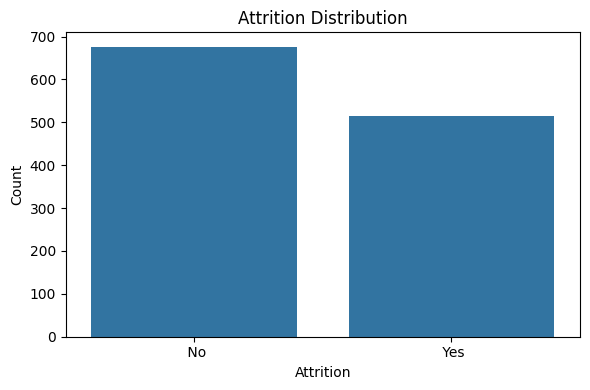

In [9]:
# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition", order=df["Attrition"].value_counts().index)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Attrition Insight 

The attrition rate is 43.24% of employees leaving the organization.

Although the majority (56.76%) stayed the gap between stayers and leavers is not large,

show a moderately balanced target variable.

Since the dataset is not heavily imbalanced, predictive modeling will not suffer


## detect categorical vs numeric columns

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

id_like_cols = [c for c in df.columns if c.strip().lower() in ["id"]]

print("\nDetected numeric columns:", numeric_cols)
print("Detected categorical columns:", categorical_cols)



Detected numeric columns: ['ID', 'Allowances']
Detected categorical columns: ['Attrition', 'Gender ', 'Age', ' Maritalstatus', '\xa0Academic_degree ', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']


## Categorical feature Anaysis 

### Gender Distribution

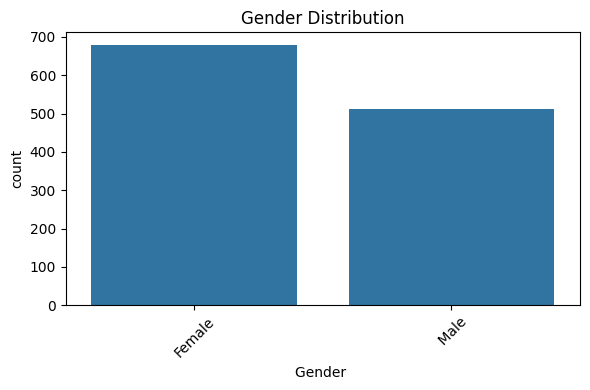

In [11]:
plt.figure(figsize=(6,4))
order = df["Gender "].value_counts().index

sns.countplot(data=df, x="Gender ", order=order)
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


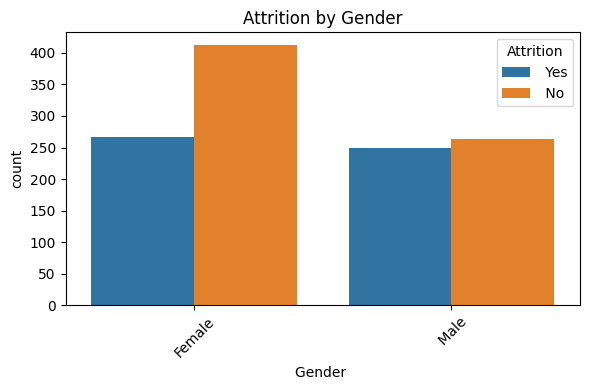

In [12]:
plt.figure(figsize=(6,4))
order = df["Gender "].value_counts().index

sns.countplot(data=df, x="Gender ", hue="Attrition", order=order)
plt.title("Attrition by Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top 10 Departments Distribution

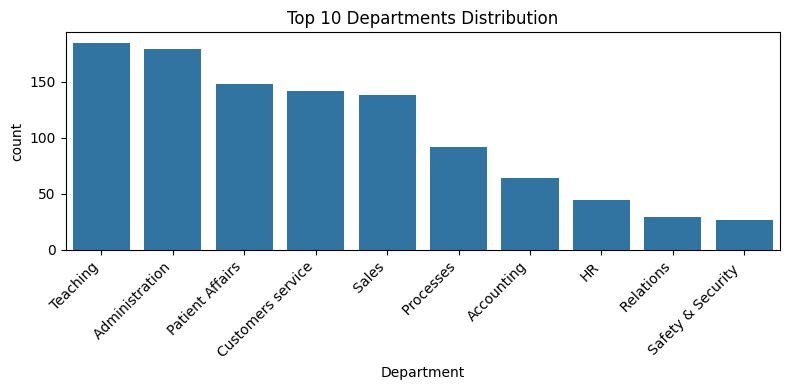

In [13]:
plt.figure(figsize=(8,4))
top_departments = df["Department"].value_counts().head(10).index

sns.countplot(data=df[df["Department"].isin(top_departments)],
              x="Department",
              order=top_departments)

plt.title("Top 10 Departments Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


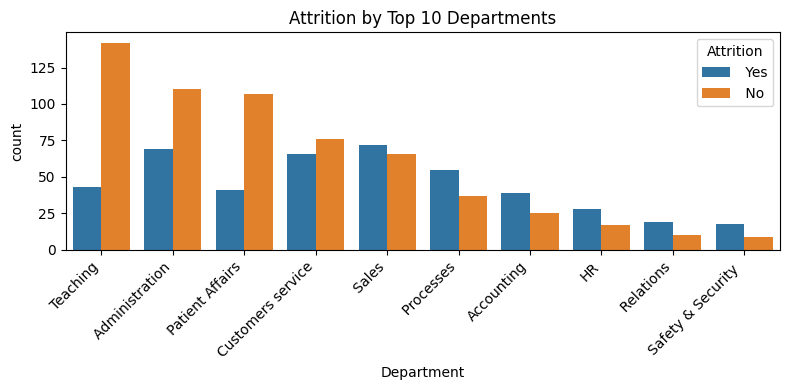

In [14]:
plt.figure(figsize=(8,4))

sns.countplot(data=df[df["Department"].isin(top_departments)],
              x="Department",
              hue="Attrition",
              order=top_departments)

plt.title("Attrition by Top 10 Departments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:

df["Department"] = df["Department"].astype(str).str.strip()
df["Attrition"] = df["Attrition"].astype(str).str.strip()

dept_attrition = (
    df.groupby(["Department", "Attrition"])
    .size()
    .unstack(fill_value=0)
)

dept_pct = (
    dept_attrition.div(dept_attrition.sum(axis=1), axis=0) * 100
).round(1)

dept_order = df["Department"].value_counts().index

output_lines = []
output_lines.append("Attrition by Department")

for i, dept in enumerate(dept_order, start=1):
    if dept not in dept_attrition.index:
        continue
    
    yes_count = dept_attrition.loc[dept].get("Yes", 0)
    no_count  = dept_attrition.loc[dept].get("No", 0)
    
    yes_pct = dept_pct.loc[dept].get("Yes", 0)
    no_pct  = dept_pct.loc[dept].get("No", 0)
    
    output_lines.append(f"\n{i}. Department: {dept}")
    output_lines.append("------------------------------------------------")
    output_lines.append(f"   Attrition = Yes  → {yes_count} employees  ({yes_pct}%)")
    output_lines.append(f"   Attrition = No   → {no_count} employees  ({no_pct}%)")



for line in output_lines:
    print(line)

# حفظ في ملف نصي
file_path = "../reports/Attrition_by_Department_Report.txt"
with open(file_path, "w", encoding="utf-8") as f:
    for line in output_lines:
        f.write(line + "\n")

print(f"\nReport saved to: {os.path.abspath(file_path)}")

Attrition by Department

1. Department: Administration
------------------------------------------------
   Attrition = Yes  → 74 employees  (38.1%)
   Attrition = No   → 120 employees  (61.9%)

2. Department: Teaching
------------------------------------------------
   Attrition = Yes  → 43 employees  (23.2%)
   Attrition = No   → 142 employees  (76.8%)

3. Department: Patient Affairs
------------------------------------------------
   Attrition = Yes  → 41 employees  (27.7%)
   Attrition = No   → 107 employees  (72.3%)

4. Department: Customers service
------------------------------------------------
   Attrition = Yes  → 66 employees  (46.5%)
   Attrition = No   → 76 employees  (53.5%)

5. Department: Sales
------------------------------------------------
   Attrition = Yes  → 72 employees  (52.2%)
   Attrition = No   → 66 employees  (47.8%)

6. Department: Processes
------------------------------------------------
   Attrition = Yes  → 56 employees  (56.6%)
   Attrition = No   → 43 

### Job Support Distribution

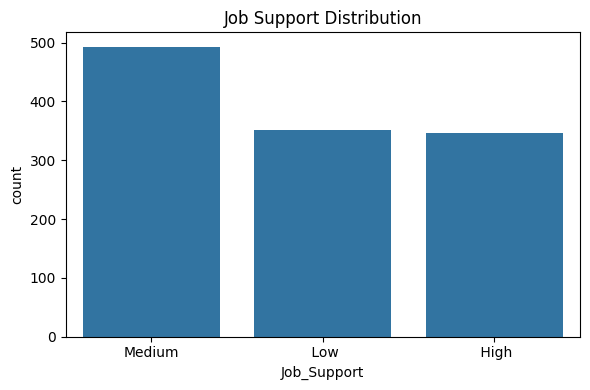

In [16]:
plt.figure(figsize=(6,4))
order = df["Job_Support"].value_counts().index

sns.countplot(data=df, x="Job_Support", order=order)
plt.title("Job Support Distribution")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


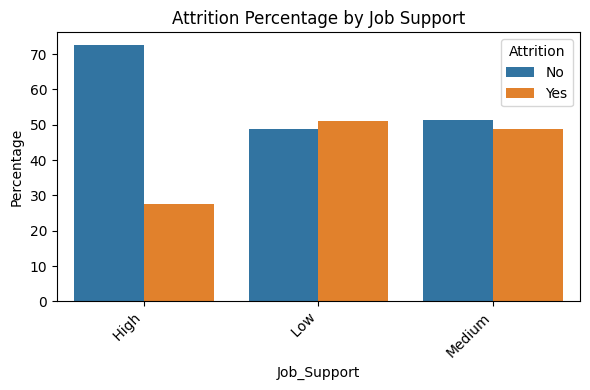

In [17]:
support_attrition = (
    df.groupby(["Job_Support", "Attrition"])
      .size()
      .reset_index(name="count")
)

support_attrition["percentage"] = (
    support_attrition.groupby("Job_Support")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(6,4))
sns.barplot(data=support_attrition,
            x="Job_Support",
            y="percentage",
            hue="Attrition")

plt.title("Attrition Percentage by Job Support")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Marital Status Distribution

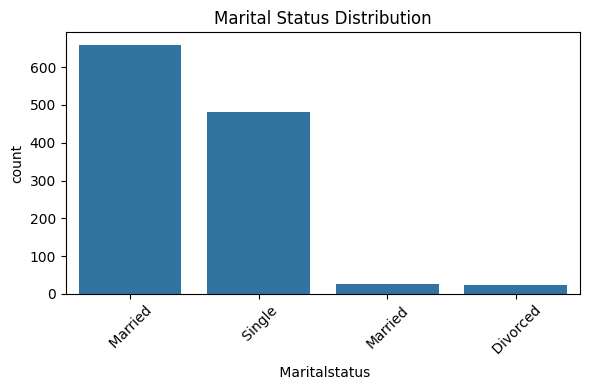

In [18]:
plt.figure(figsize=(6,4))
order = df[" Maritalstatus"].value_counts().index

sns.countplot(data=df, x=" Maritalstatus", order=order)
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df[" Maritalstatus"].unique()

array([' Married', ' Single', 'Married', ' Divorced'], dtype=object)

The Maritalstatus feature contains inconsistent category formatting.
 For example, 'Married' ' Married'

i will clean it here just to have batter chart

In [20]:
df[" Maritalstatus"] = df[" Maritalstatus"].str.strip()
df[" Maritalstatus"].unique()


array(['Married', 'Single', 'Divorced'], dtype=object)

In [21]:
df[" Maritalstatus"] = df[" Maritalstatus"].str.strip()
df[" Maritalstatus"].unique()

array(['Married', 'Single', 'Divorced'], dtype=object)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


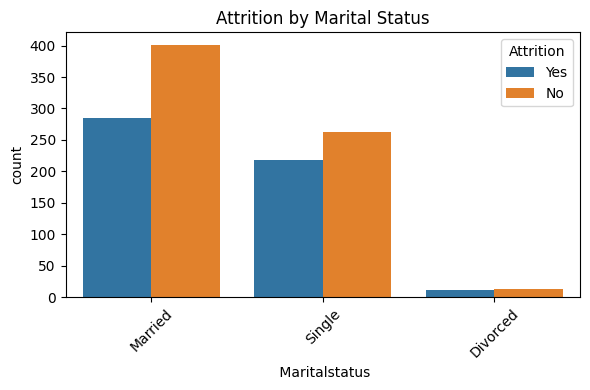

In [22]:
plt.figure(figsize=(6,4))

order = df[" Maritalstatus"].value_counts().index

sns.countplot(data=df,
              x=" Maritalstatus",
              hue="Attrition",
              order=order)

plt.title("Attrition by Marital Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Academic Degree Distribution

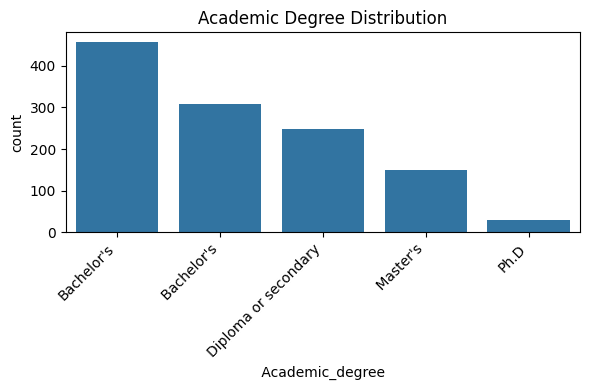

In [23]:
plt.figure(figsize=(6,4))
order = df["\xa0Academic_degree "].value_counts().index

sns.countplot(data=df, x="\xa0Academic_degree ", order=order)
plt.title("Academic Degree Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
df["\xa0Academic_degree "].unique()

array([" Master's", " Bachelor's", 'Diploma or secondary', 'Ph.D',
       "Bachelor's"], dtype=object)

here cluomn name need clean and bachelor 

In [25]:
df["\xa0Academic_degree "] = df["\xa0Academic_degree "].str.strip()
df["\xa0Academic_degree "].unique()

array(["Master's", "Bachelor's", 'Diploma or secondary', 'Ph.D'],
      dtype=object)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


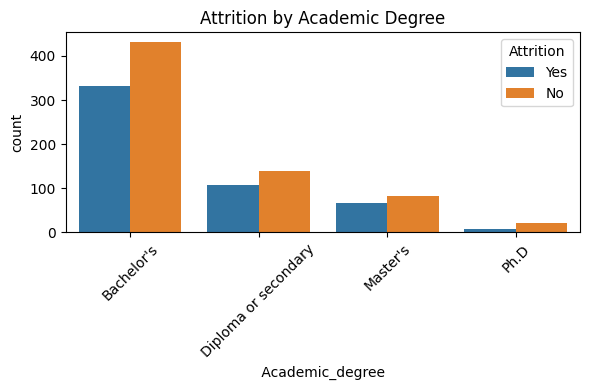

In [26]:
plt.figure(figsize=(6,4))

order = df["\xa0Academic_degree "].value_counts().index

sns.countplot(data=df,
              x="\xa0Academic_degree ",
              hue="Attrition",
              order=order)

plt.title("Attrition by Academic Degree")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sector

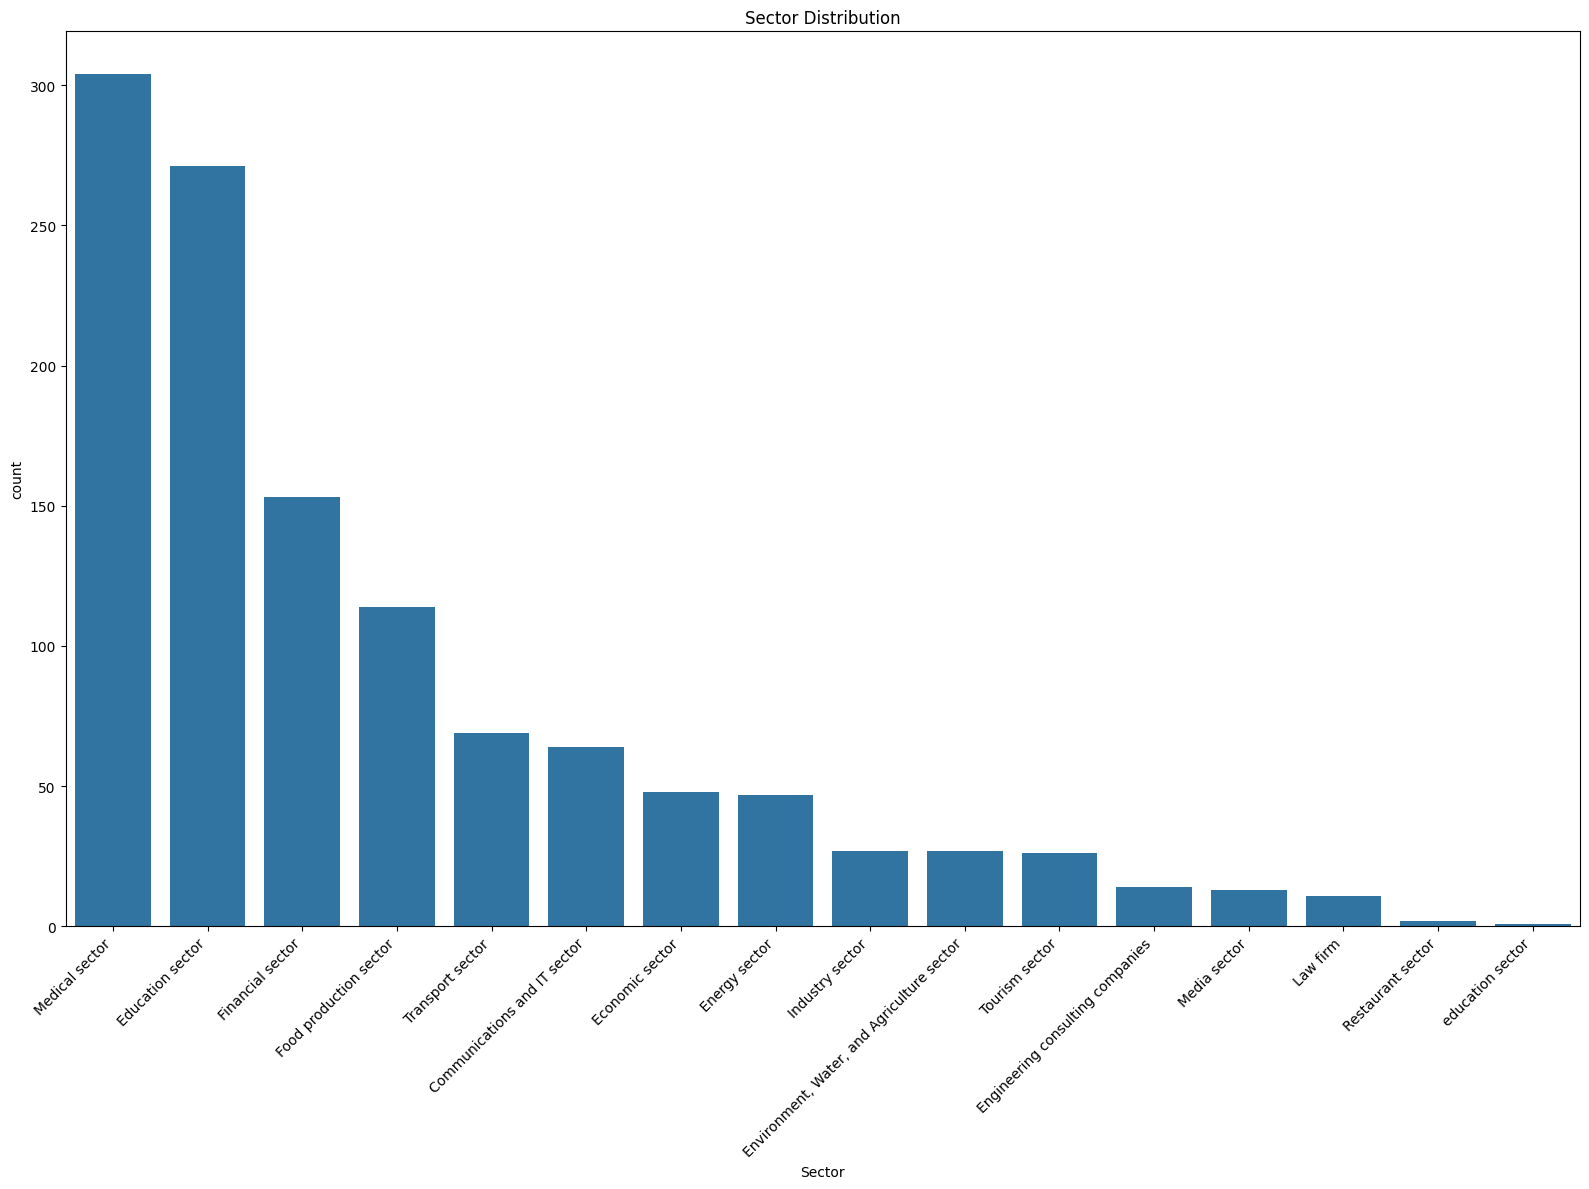

In [27]:
plt.figure(figsize=(16,12))
order = df["Sector"].value_counts().index

sns.countplot(data=df, x="Sector", order=order)
plt.title("Sector Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
df["Sector"].unique()

array(['Medical sector', 'Education sector',
       'Communications and IT sector', 'Tourism sector',
       'Financial sector', 'Economic sector', 'Transport sector',
       'Food production sector', 'Industry sector', 'Media sector',
       'Engineering consulting companies',
       'Environment, Water, and Agriculture sector', 'Law firm',
       ' Energy sector', 'Restaurant sector', 'education sector'],
      dtype=object)

In [29]:
df["Sector"] = df["Sector"].str.strip()      # إزالة المسافات
df["Sector"] = df["Sector"].str.title()     # توحيد شكل الحروف
df["Sector"].unique()

array(['Medical Sector', 'Education Sector',
       'Communications And It Sector', 'Tourism Sector',
       'Financial Sector', 'Economic Sector', 'Transport Sector',
       'Food Production Sector', 'Industry Sector', 'Media Sector',
       'Engineering Consulting Companies',
       'Environment, Water, And Agriculture Sector', 'Law Firm',
       'Energy Sector', 'Restaurant Sector'], dtype=object)

التعديلات هنا فقط لعمل الفيجواليزيشن 

['Medical Sector' 'Education Sector' 'Communications And It Sector'
 'Tourism Sector' 'Financial Sector' 'Economic Sector' 'Transport Sector'
 'Food Production Sector' 'Industry Sector' 'Media Sector'
 'Engineering Consulting Companies'
 'Environment, Water, And Agriculture Sector' 'Law Firm' 'Energy Sector'
 'Restaurant Sector']


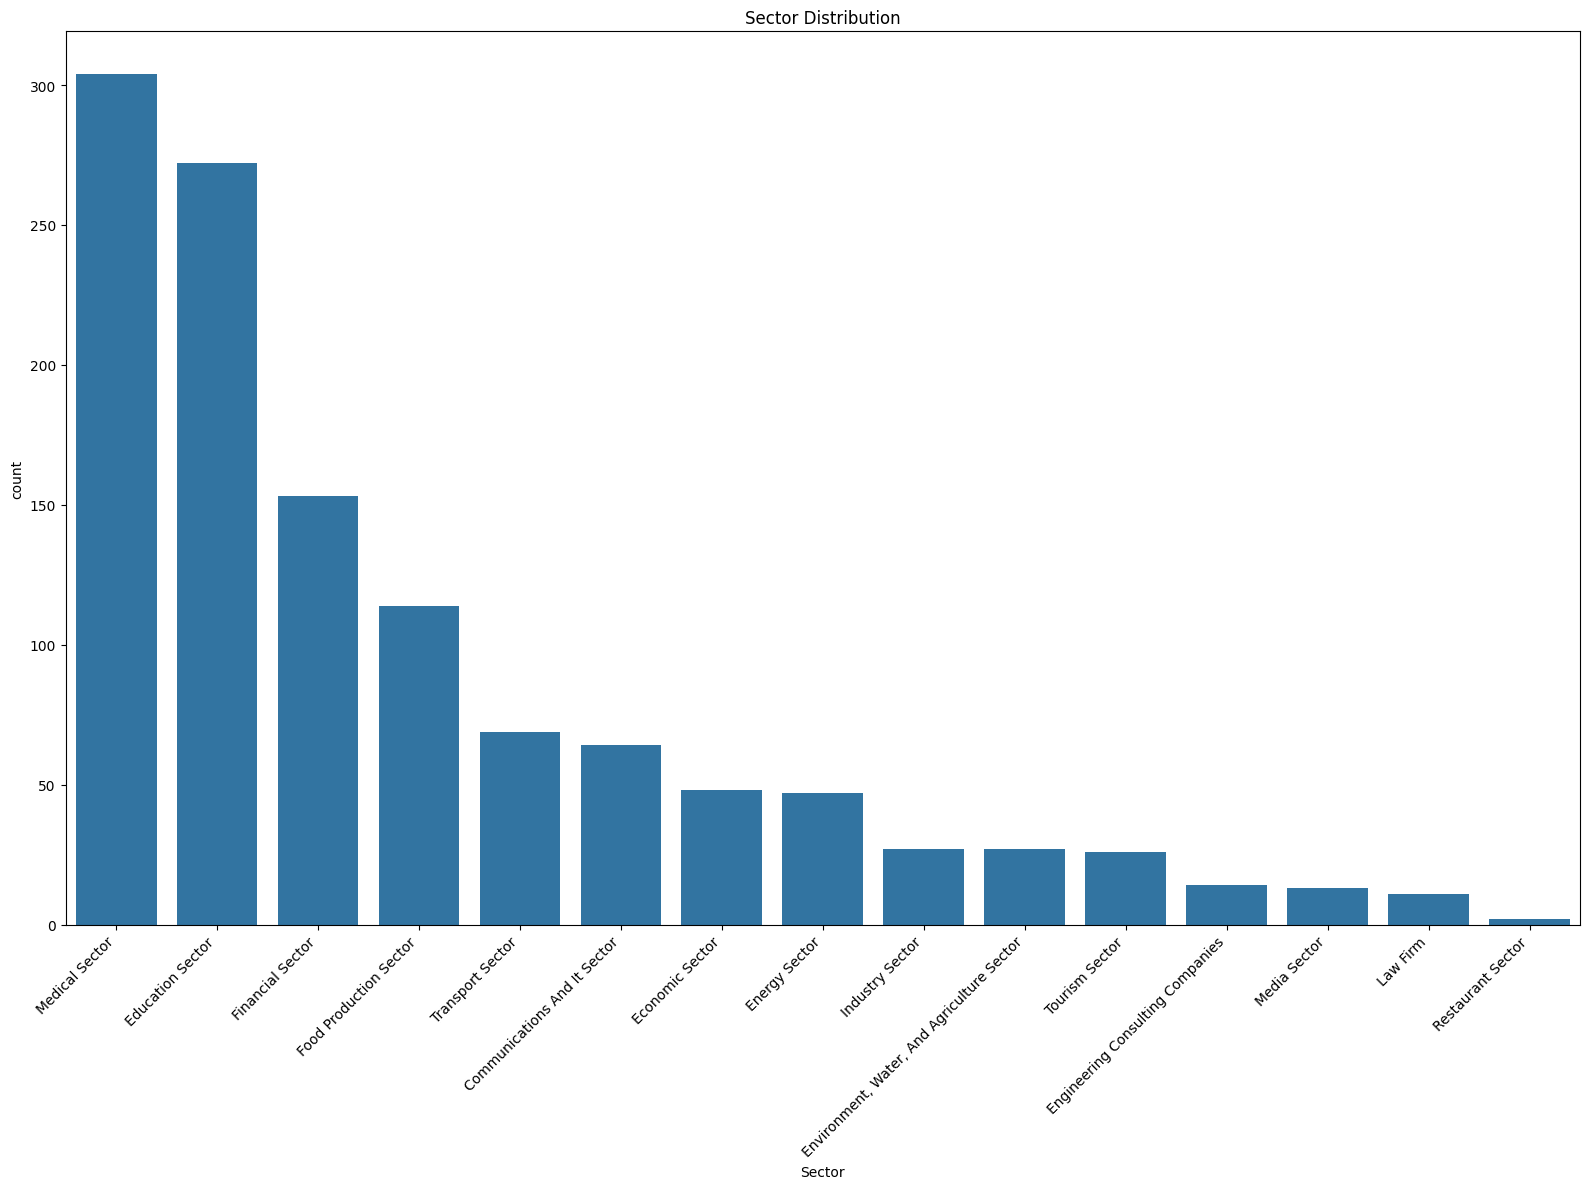

In [30]:
print(df["Sector"].unique())
plt.figure(figsize=(16,12))
order = df["Sector"].value_counts().index

sns.countplot(data=df, x="Sector", order=order)
plt.title("Sector Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


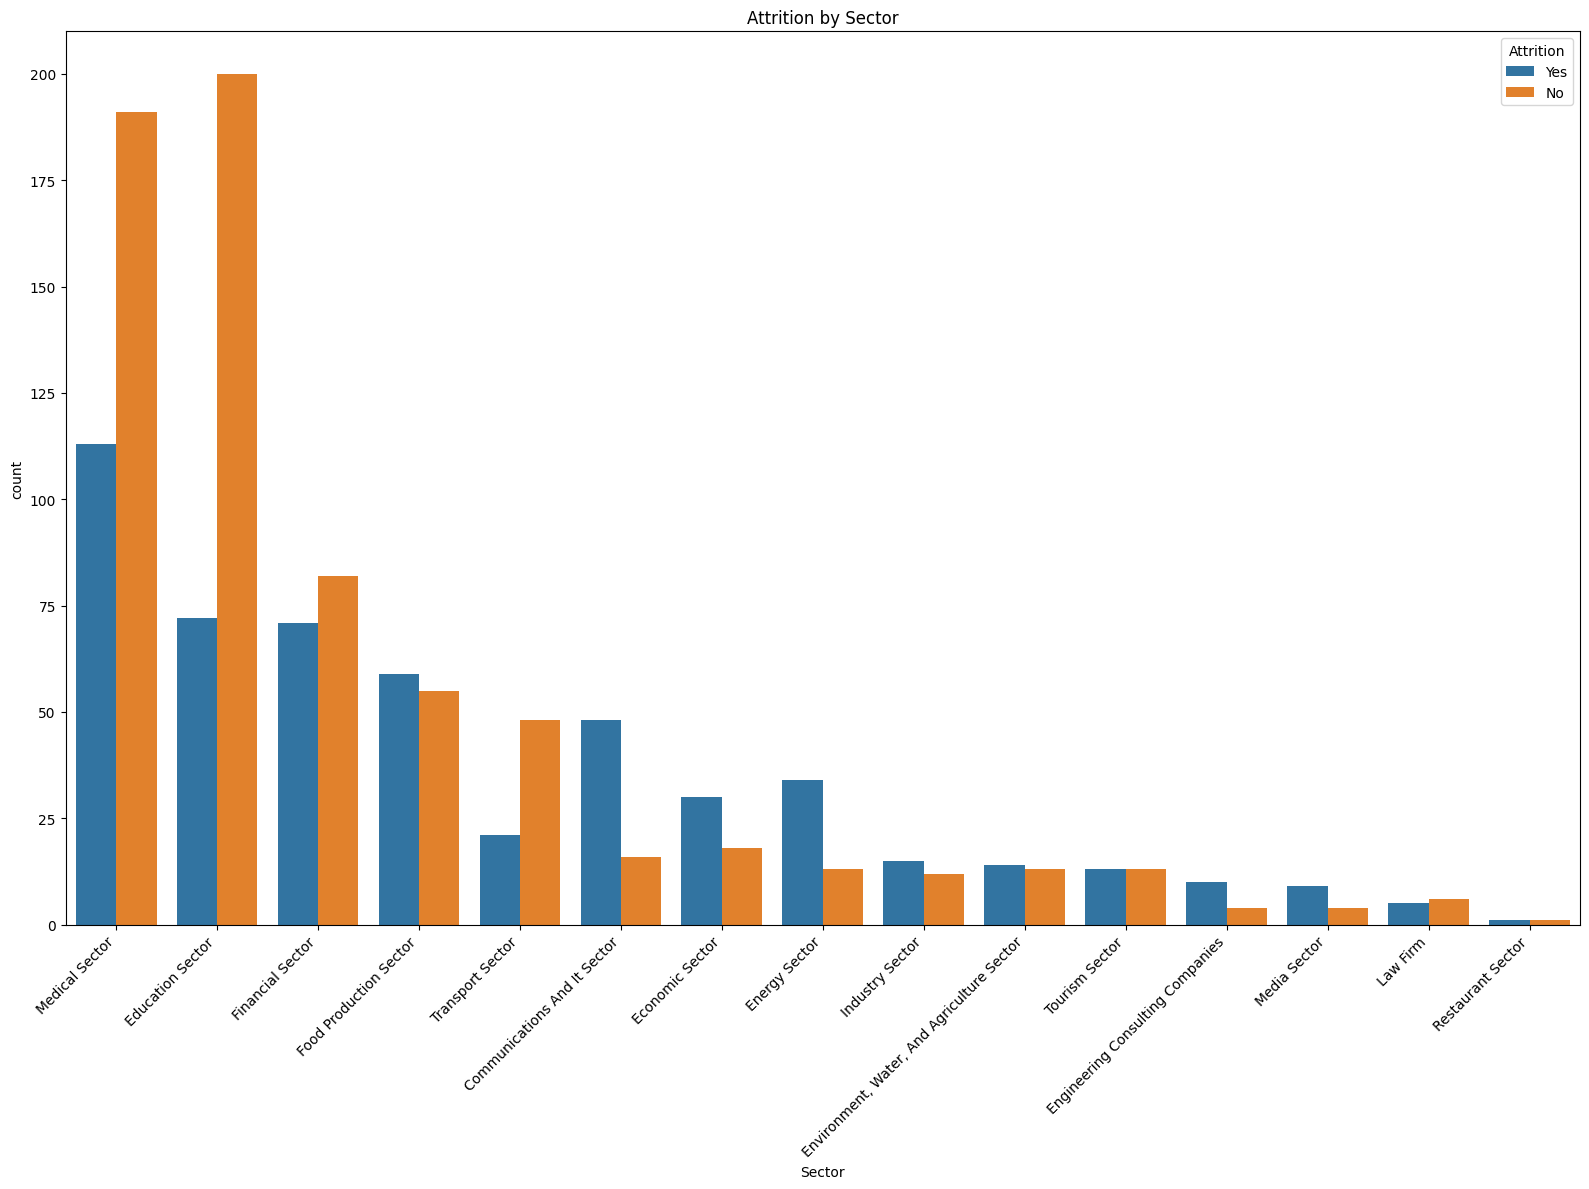

In [31]:
plt.figure(figsize=(16,12))
sns.countplot(data=df, x="Sector", hue="Attrition", order=order)
plt.title("Attrition by Sector")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# تنظيف المسافات
df["Sector"] = df["Sector"].astype(str).str.strip()
df["Attrition"] = df["Attrition"].astype(str).str.strip()

sector_attrition = (
    df.groupby(["Sector", "Attrition"])
    .size()
    .unstack(fill_value=0)
)

sector_pct = (
    sector_attrition.div(sector_attrition.sum(axis=1), axis=0) * 100
).round(1)


sector_order = df["Sector"].value_counts().index

output_lines = []
output_lines.append("Attrition by Sector")

for i, sector in enumerate(sector_order, start=1):
    if sector not in sector_attrition.index:
        continue
    
    yes_count = sector_attrition.loc[sector].get("Yes", 0)
    no_count  = sector_attrition.loc[sector].get("No", 0)
    
    yes_pct = sector_pct.loc[sector].get("Yes", 0)
    no_pct  = sector_pct.loc[sector].get("No", 0)
    
    output_lines.append(f"\n{i}. Sector: {sector}")
    output_lines.append("------------------------------------------------------")
    output_lines.append(f"   Attrition = Yes  → {yes_count} employees  ({yes_pct}%)")
    output_lines.append(f"   Attrition = No   → {no_count} employees  ({no_pct}%)")

output_lines.append("Report Complete")


for line in output_lines:
    print(line)

# حفظ في ملف
file_path = "../reports/Attrition_by_Sector_Report.txt"
with open(file_path, "w", encoding="utf-8") as f:
    for line in output_lines:
        f.write(line + "\n")

print(f"\nReport saved to: {os.path.abspath(file_path)}")

Attrition by Sector

1. Sector: Medical Sector
------------------------------------------------------
   Attrition = Yes  → 113 employees  (37.2%)
   Attrition = No   → 191 employees  (62.8%)

2. Sector: Education Sector
------------------------------------------------------
   Attrition = Yes  → 72 employees  (26.5%)
   Attrition = No   → 200 employees  (73.5%)

3. Sector: Financial Sector
------------------------------------------------------
   Attrition = Yes  → 71 employees  (46.4%)
   Attrition = No   → 82 employees  (53.6%)

4. Sector: Food Production Sector
------------------------------------------------------
   Attrition = Yes  → 59 employees  (51.8%)
   Attrition = No   → 55 employees  (48.2%)

5. Sector: Transport Sector
------------------------------------------------------
   Attrition = Yes  → 21 employees  (30.4%)
   Attrition = No   → 48 employees  (69.6%)

6. Sector: Communications And It Sector
------------------------------------------------------
   Attrition = Ye

### "Top 10 Job Titles

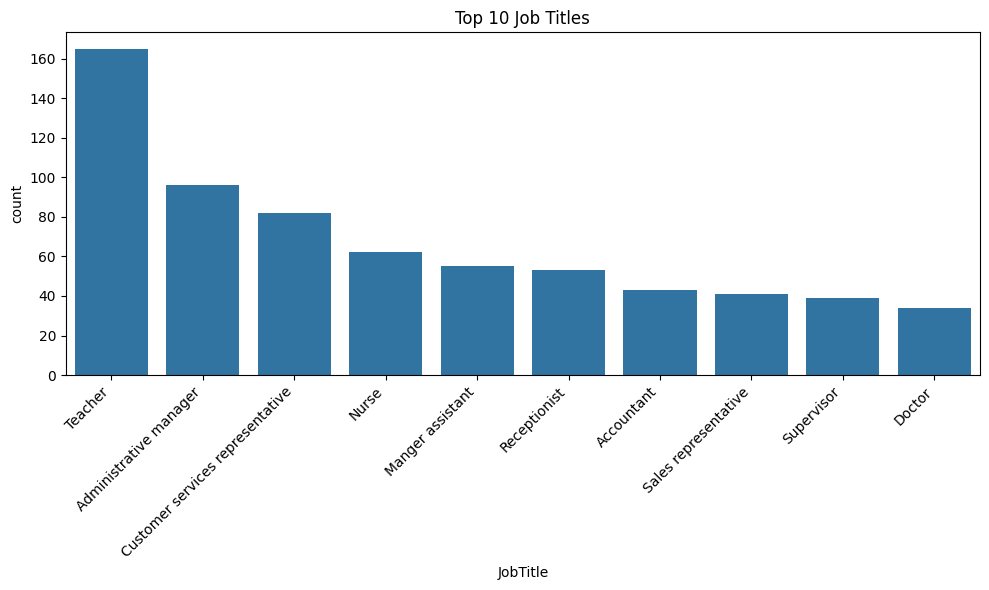

In [33]:
plt.figure(figsize=(10,6))
top_jobs = df["JobTitle"].value_counts().head(10).index

sns.countplot(data=df[df["JobTitle"].isin(top_jobs)],
              x="JobTitle",
              order=top_jobs)

plt.title("Top 10 Job Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
df["JobTitle"].unique()

array(['Accountant', 'Teacher', 'Relationships Specialist',
       'Manger assistant', 'Administrative manager', 'Project manager',
       'Banking operations', ' Coordinator',
       'Customer services representative', 'Lecturer', 'Scribe',
       'Sales executive', 'Sales representative', 'Salesman',
       'Consultant', 'Security and safety specialist',
       'Admin accountant ', 'IT specialist ', 'Trainer',
       'Cybersecurity director', 'Doctor', 'HR Specialist ',
       'Operations Supervisor ', 'Data entry operator',
       'Quality Specialist', 'Marketing Specialist',
       'Application specialist ', 'Chemical Engineer ', 'Lawyer ',
       'Driver', 'Secretariat', 'Electrical engineer', 'Supervisor',
       'Nurse', 'Treasury agent', 'Receptionist', 'Head of treasury',
       'Quality controller', 'Hiring specialist', 'Warehouse officer',
       'Mechanical engineer ', 'Production supervisor', 'Pharmacist',
       'Reports Manager', 'Radiographer ', 'Radiographer', 'Dentist

need cleaning 

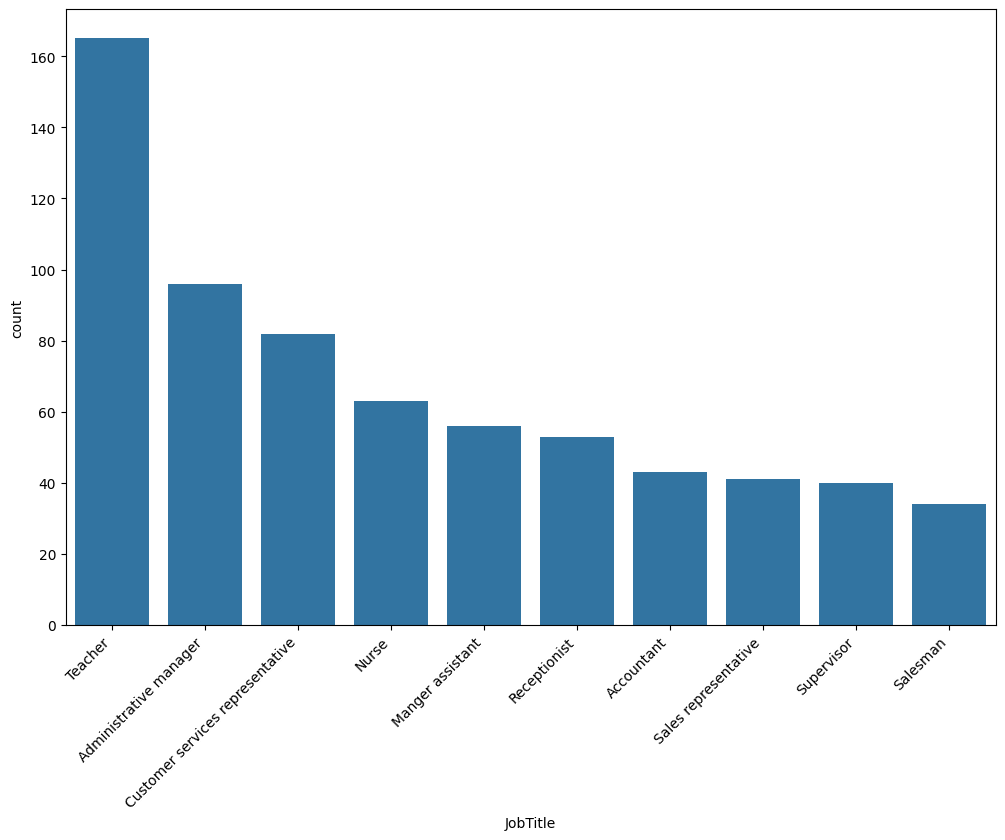

In [35]:
cleaned = df["JobTitle"].str.strip()

top_jobs = cleaned.value_counts().head(10).index
plt.figure(figsize=(12,8))

sns.countplot(
    data=df[df["JobTitle"].str.strip().isin(top_jobs)],
    x=cleaned,
    order=top_jobs
)

plt.xticks(rotation=45, ha="right")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


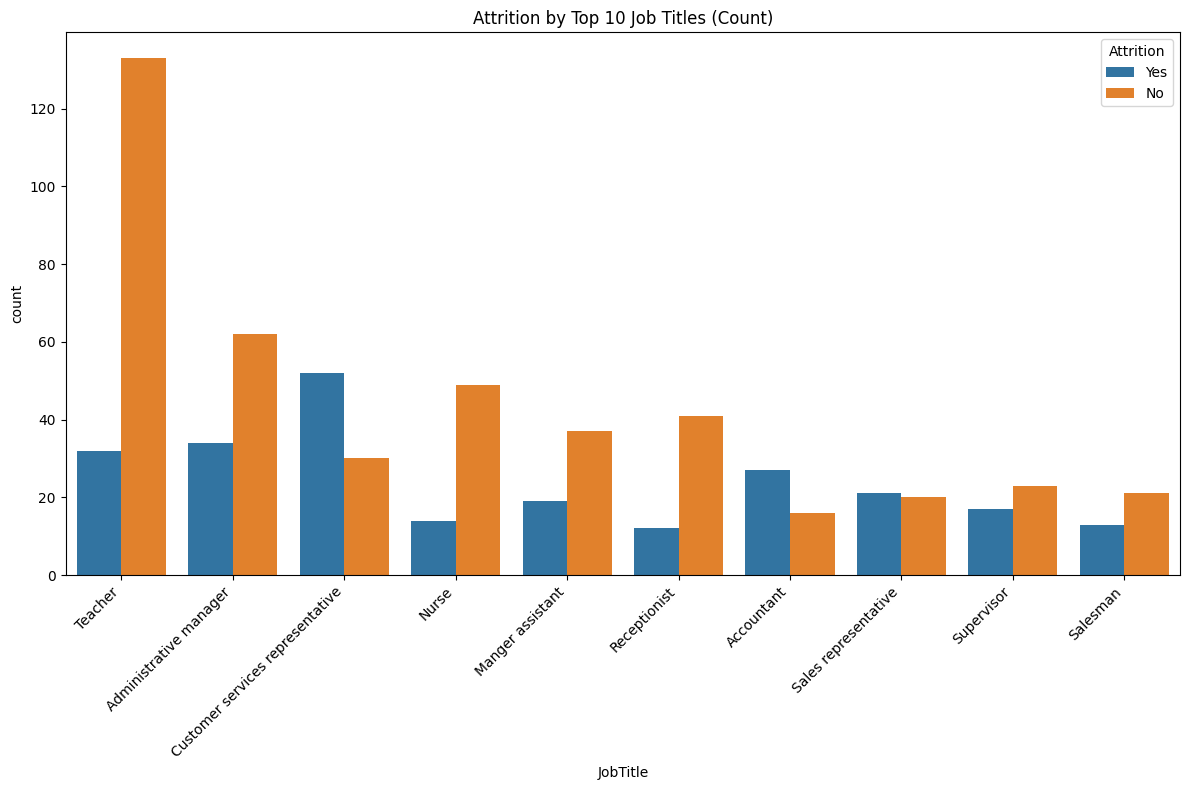

In [36]:
plt.figure(figsize=(12,8))

# تنظيف مؤقت بدون تعديل الداتا
job_clean = df["JobTitle"].str.strip()

top_jobs = job_clean.value_counts().head(10).index

sns.countplot(
    data=df[job_clean.isin(top_jobs)],
    x=job_clean[job_clean.isin(top_jobs)],
    hue="Attrition",
    order=top_jobs
)

plt.title("Attrition by Top 10 Job Titles (Count)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
df["JobTitle"] = df["JobTitle"].astype(str).str.strip()
df["Attrition"] = df["Attrition"].astype(str).str.strip()


job_attrition = (
    df.groupby(["JobTitle", "Attrition"])
    .size()
    .unstack(fill_value=0)
)


job_pct = (
    job_attrition.div(job_attrition.sum(axis=1), axis=0) * 100
).round(1)


job_order = df["JobTitle"].value_counts().index

output_lines = []

output_lines.append("Attrition by Job Title (Numbered Report)")


for i, job in enumerate(job_order, start=1):
    if job not in job_attrition.index:
        continue
    
    yes_count = job_attrition.loc[job].get("Yes", 0)
    no_count  = job_attrition.loc[job].get("No", 0)
    
    yes_pct = job_pct.loc[job].get("Yes", 0)
    no_pct  = job_pct.loc[job].get("No", 0)
    
    output_lines.append(f"\n{i}. Job Title: {job}")
    output_lines.append("-----------------------------------------------")
    output_lines.append(f"   Attrition = Yes  → {yes_count} employees  ({yes_pct}%)")
    output_lines.append(f"   Attrition = No   → {no_count} employees  ({no_pct}%)")






for line in output_lines:
    print(line)

# Save to file
file_path = "../reports/Attrition_by_JobTitle_Report.txt"
with open(file_path, "w", encoding="utf-8") as f:
    for line in output_lines:
        f.write(line + "\n")

print(f"\nReport saved to: {os.path.abspath(file_path)}")

Attrition by Job Title (Numbered Report)

1. Job Title: Teacher
-----------------------------------------------
   Attrition = Yes  → 32 employees  (19.4%)
   Attrition = No   → 133 employees  (80.6%)

2. Job Title: Administrative manager
-----------------------------------------------
   Attrition = Yes  → 34 employees  (35.4%)
   Attrition = No   → 62 employees  (64.6%)

3. Job Title: Customer services representative
-----------------------------------------------
   Attrition = Yes  → 52 employees  (63.4%)
   Attrition = No   → 30 employees  (36.6%)

4. Job Title: Nurse
-----------------------------------------------
   Attrition = Yes  → 14 employees  (22.2%)
   Attrition = No   → 49 employees  (77.8%)

5. Job Title: Manger assistant
-----------------------------------------------
   Attrition = Yes  → 19 employees  (33.9%)
   Attrition = No   → 37 employees  (66.1%)

6. Job Title: Receptionist
-----------------------------------------------
   Attrition = Yes  → 12 employees  (22.

### Business Trave

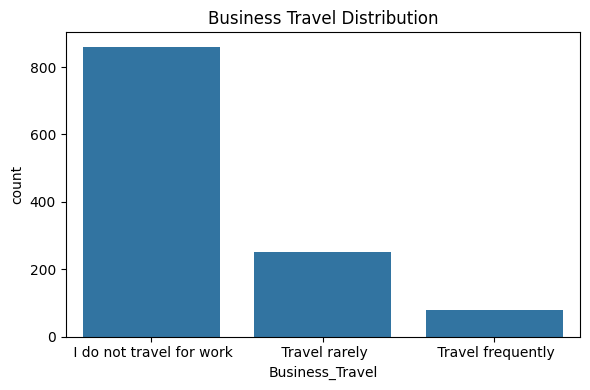

In [38]:
plt.figure(figsize=(6,4))
order = df["Business_Travel"].value_counts().index

sns.countplot(data=df, x="Business_Travel", order=order)
plt.title("Business Travel Distribution")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


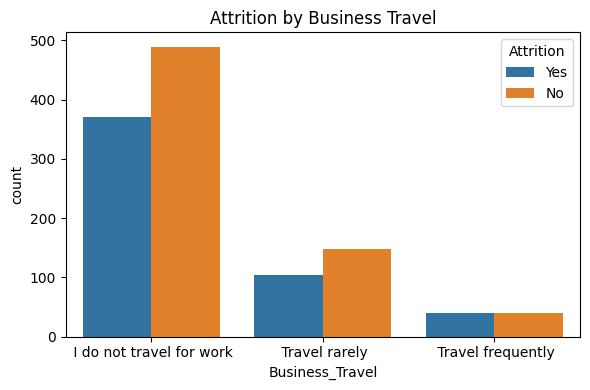

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Business_Travel", hue="Attrition", order=order)
plt.title("Attrition by Business Travel")
plt.tight_layout()
plt.show()

### Attrition Percentage by Job Support

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


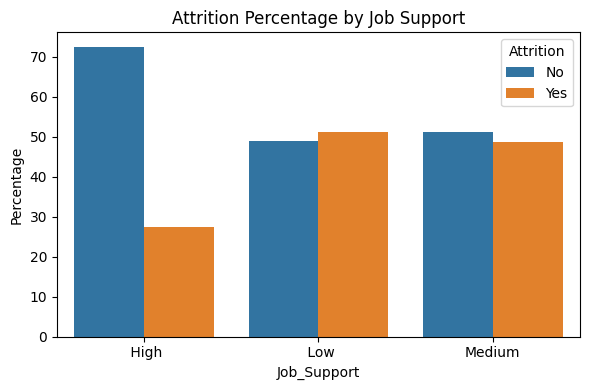

In [40]:
support_attr = (
    df.groupby(["Job_Support", "Attrition"])
      .size()
      .reset_index(name="count")
)

support_attr["percentage"] = (
    support_attr.groupby("Job_Support")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(6,4))
sns.barplot(data=support_attr,
            x="Job_Support",
            y="percentage",
            hue="Attrition")

plt.title("Attrition Percentage by Job Support")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

### Attrition by Recognition


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


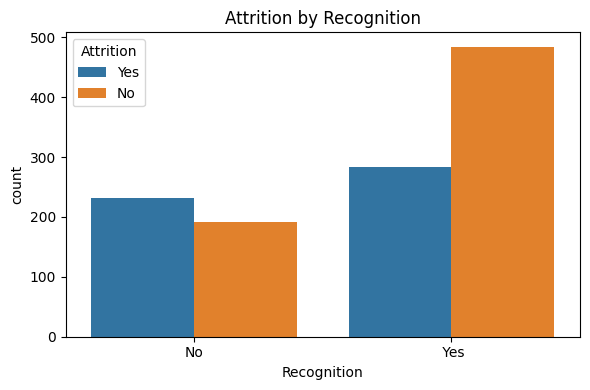

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Recognition", hue="Attrition")
plt.title("Attrition by Recognition")
plt.tight_layout()
plt.show()

### Attrition by Work Life Balance

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


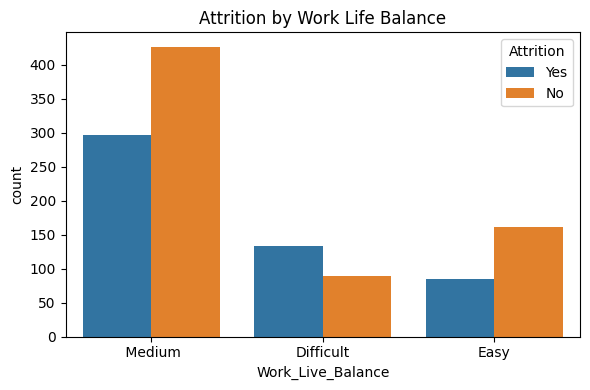

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Work_Live_Balance", hue="Attrition")
plt.title("Attrition by Work Life Balance")
plt.tight_layout()
plt.show()

### Attrition by Job Satisfaction

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


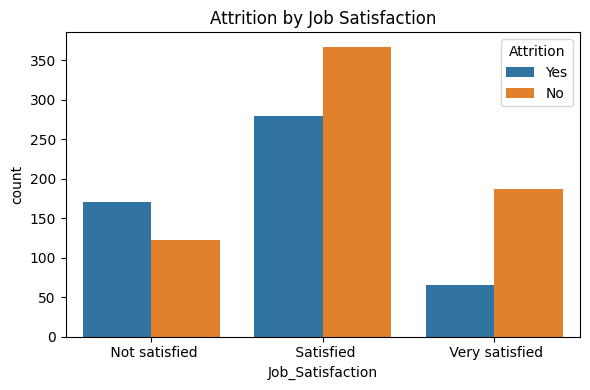

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Job_Satisfaction", hue="Attrition")
plt.title("Attrition by Job Satisfaction")
plt.tight_layout()
plt.show()

### Attrition by Psychological Exhaustion

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


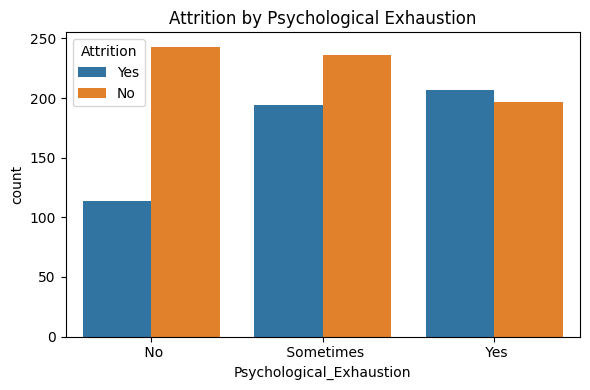

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Psychological_Exhaustion", hue="Attrition")
plt.title("Attrition by Psychological Exhaustion")
plt.tight_layout()
plt.show()

### Age Group Analysis

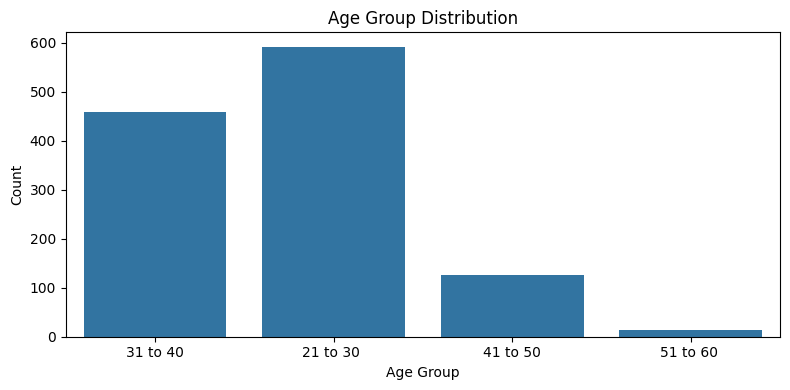

In [45]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x="Age")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


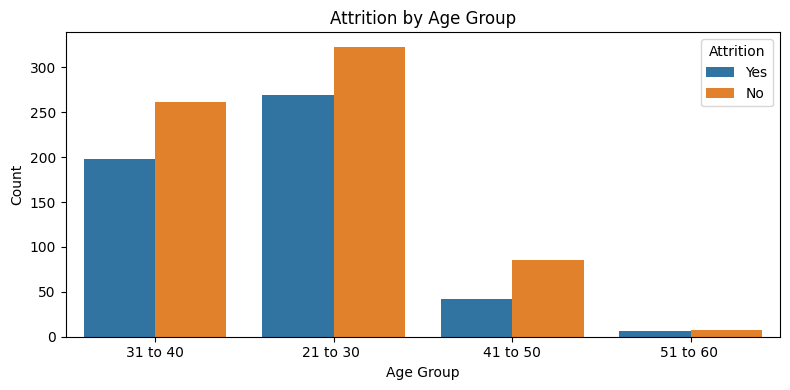

In [46]:

# نسبة الخروج لكل فئة عمرية
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Age", hue="Attrition")
plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Monthly Salary Analysis

<Figure size 1000x400 with 0 Axes>

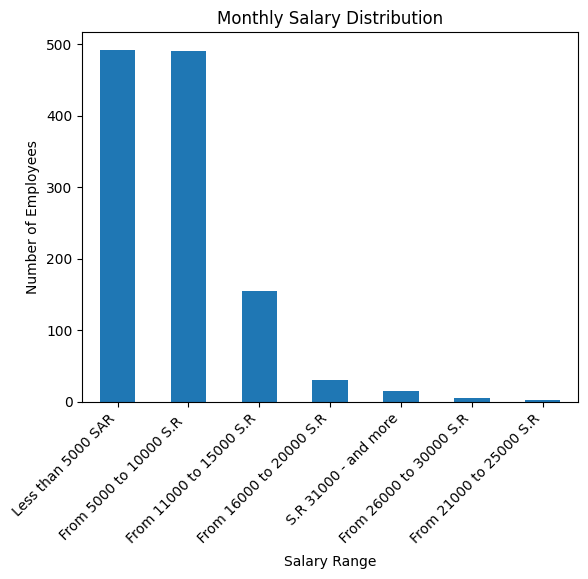

In [47]:

plt.figure(figsize=(10,4))
salary_counts = df['MonthlySalary'].value_counts()

# رسم
plt.figure()
salary_counts.plot(kind='bar')

plt.title("Monthly Salary Distribution")
plt.xlabel("Salary Range")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")

plt.show()


Attrition                  No  Yes
MonthlySalary                     
 From 16000 to 20000 S.R   15   16
 From 5000 to 10000 S.R   291  200
 S.R 31000 - and more      11    4
From 11000 to 15000 S.R    85   70
From 21000 to 25000 S.R     1    1
Less than 5000 SAR        271  221
 From 26000 to 30000 S.R    2    3


<Figure size 1000x400 with 0 Axes>

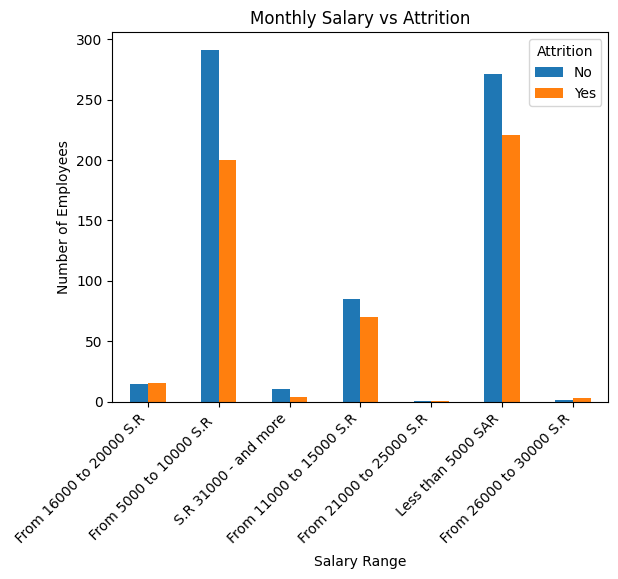

In [48]:

salary_attrition = pd.crosstab(df['MonthlySalary'], df['Attrition'])

print(salary_attrition)


plt.figure(figsize=(10,4))
salary_attrition.plot(kind='bar')

plt.title("Monthly Salary vs Attrition")
plt.xlabel("Salary Range")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")

plt.show()

### OverTime Analysis

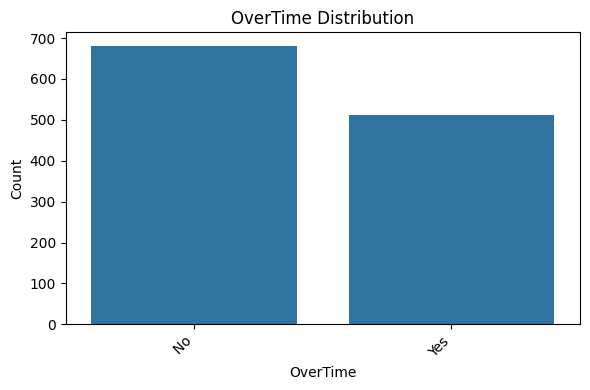

In [49]:
plt.figure(figsize=(6,4))
overtime_order = df["OverTime"].value_counts().index

sns.countplot(data=df, x="OverTime", order=overtime_order)
plt.title("OverTime Distribution")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


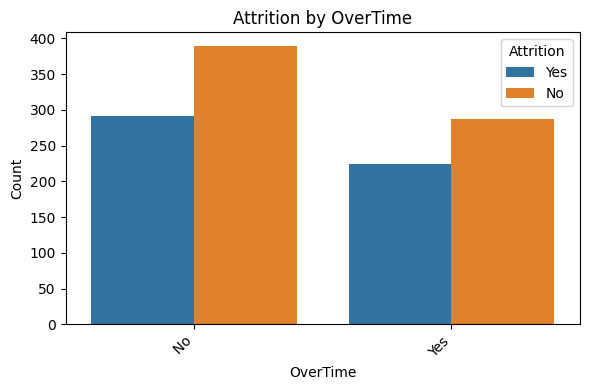

In [50]:
# عدد الخروج حسب الـ OverTime
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="OverTime", hue="Attrition", order=overtime_order)
plt.title("Attrition by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Promotion Analysis


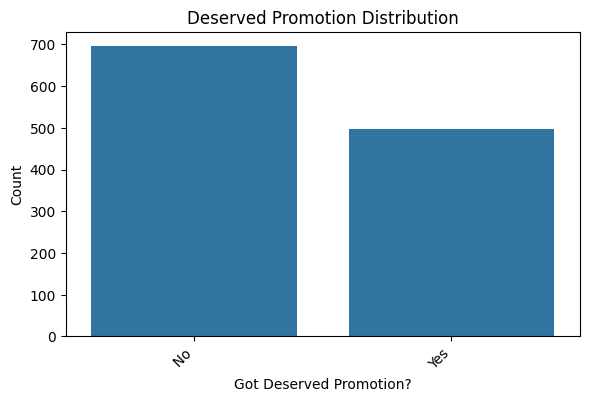

In [51]:

plt.figure(figsize=(6,4))
promo_order = df["Get_ Deserved_Promotion"].value_counts().index

sns.countplot(data=df, x="Get_ Deserved_Promotion", order=promo_order)
plt.title("Deserved Promotion Distribution")
plt.xlabel("Got Deserved Promotion?")
plt.ylabel("Count")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")

plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


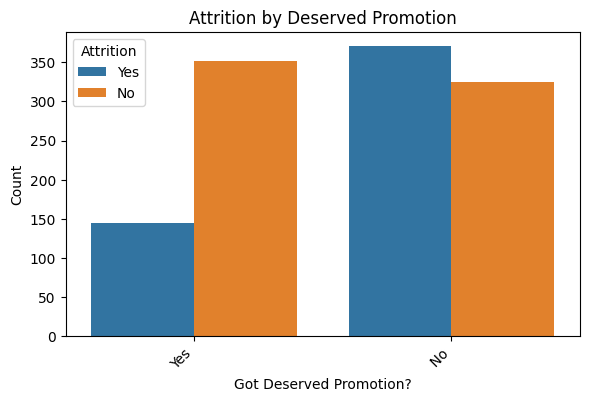

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Get_ Deserved_Promotion", hue="Attrition")
plt.title("Attrition by Deserved Promotion")
plt.xlabel("Got Deserved Promotion?")
plt.ylabel("Count")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()



### Feelings & Wellbeing Correlation Heatmap


In [53]:
from sklearn.preprocessing import OrdinalEncoder

# الأعمدة المرتبطة بالمشاعر والضغط
feeling_cols = [
    "Work_Live_Balance",
    "Job_Satisfaction",
    "Psychological_Exhaustion",
    "Physical_Stress",
    "Emotional_Commitment",
    "Job_Engagement",
    "Environment_Satisfaction",
    "Job_Stability"
]
for col in feeling_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Work_Live_Balance
[' Medium' 'Difficult' 'Easy']

Column: Job_Satisfaction
[' Not satisfied' ' Satisfied' ' Very satisfied']

Column: Psychological_Exhaustion
[' No' ' Sometimes' ' Yes']

Column: Physical_Stress
[' Yes' ' No' ' Sometimes']

Column: Emotional_Commitment
[' Medium' 'Low' ' High']

Column: Job_Engagement
['Medium' ' Difficult' ' Easy']

Column: Environment_Satisfaction
['Medium' 'Low' ' High']

Column: Job_Stability
[' No' ' Yes']


In [54]:
df["Attrition"] = df["Attrition"].str.strip()
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
for col in feeling_cols:
    df[col] = df[col].str.strip().str.lower()

mapping_dict = {
    "Work_Live_Balance": {
        "difficult": 1,
        "medium": 2,
        "easy": 3
    },
    "Job_Satisfaction": {
        "not satisfied": 1,
        "satisfied": 2,
        "very satisfied": 3
    },
    "Psychological_Exhaustion": {
        "no": 1,
        "sometimes": 2,
        "yes": 3
    },
    "Physical_Stress": {
        "no": 1,
        "sometimes": 2,
        "yes": 3
    },
    "Emotional_Commitment": {
        "low": 1,
        "medium": 2,
        "high": 3
    },
    "Job_Engagement": {
        "difficult": 1,
        "medium": 2,
        "easy": 3
    },
    "Environment_Satisfaction": {
        "low": 1,
        "medium": 2,
        "high": 3
    },
    "Job_Stability": {
        "no": 0,
        "yes": 1
    }
}

corr_df = pd.DataFrame()

for col in mapping_dict:
    corr_df[col] = df[col].map(mapping_dict[col])

df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
corr_df["Attrition_num"] = df["Attrition_num"]

print(corr_df.isna().sum())  # لازم تطلع كلها 0 


Work_Live_Balance           0
Job_Satisfaction            0
Psychological_Exhaustion    0
Physical_Stress             0
Emotional_Commitment        0
Job_Engagement              0
Environment_Satisfaction    0
Job_Stability               0
Attrition_num               0
dtype: int64


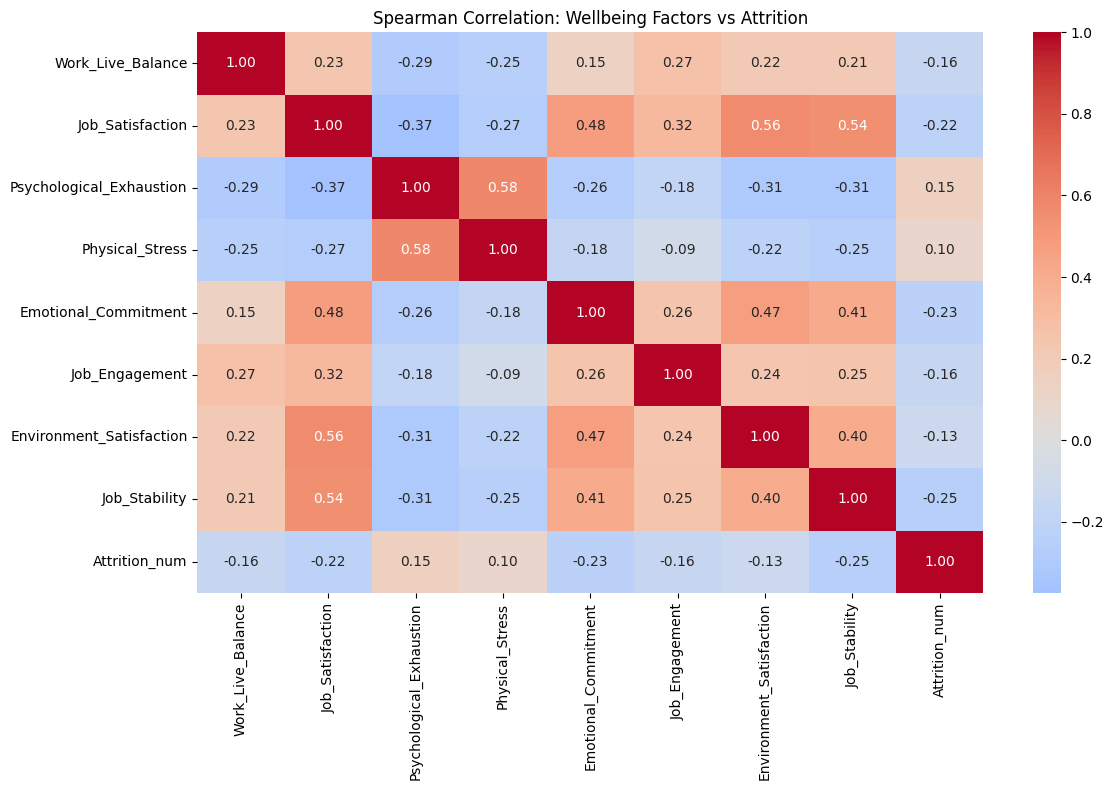

In [55]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_df.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation: Wellbeing Factors vs Attrition")
plt.tight_layout()
plt.show()

Psychological_Exhaustion -> Physical_Stress = 0.58

Psychological and physical strain are strongly interconnected, indicating potential burnout risk clusters.

Job_Satisfaction ->  Environment_Satisfaction = 0.56

Job_Satisfaction ->  Job_Stability = 0.54

Work environment is strongly associated with both satisfaction and perceived job stability.

Psychological_Exhaustion -> Job_Satisfaction = -0.37

Psychological_Exhaustion -> Job_Stability = -0.31

Psychological_Exhaustion -> Environment_Satisfaction = -0.31

As psychological exhaustion increases:

Job satisfaction decreases

Perceived job stability decreases

Evaluation of the work environment declines


### Attrition Rate by Feature Summary

In [56]:
df.columns = df.columns.str.strip()
summary_cols = [
    "Age",
    "MonthlySalary",
    "OverTime",
    "Get_ Deserved_Promotion",
    "Business_Travel",
    "Psychological_Exhaustion",
    "Job_Satisfaction",
    "Work_Live_Balance",
    "Job_Stability",
    "Gender",
    "Maritalstatus",
    "Academic_degree"
]

print("Attrition Rate by Feature Summary")


min_group_size = 20  

for col in summary_cols:
    if col not in df.columns:
        print(f"\nColumn '{col}' not found, skipping...")
        continue

    print(f"\nAttrition Rate by: {col}")
    print("------------------------------------------------------------------")


    grouped = df.groupby(col)["Attrition_num"].agg(["mean", "count"])
    
    grouped = grouped[grouped["count"] >= min_group_size]

    grouped["rate"] = (grouped["mean"] * 100).round(1)
    grouped = grouped.sort_values("rate", ascending=False)

    for category, row in grouped.iterrows():
        pct = row["rate"]
        print(f"{str(category):<35} {pct:>5}%   (n={int(row['count'])})")


Attrition Rate by Feature Summary

Attrition Rate by: Age
------------------------------------------------------------------
21 to 30                             45.4%   (n=592)
31 to 40                             43.1%   (n=459)
41 to 50                             33.1%   (n=127)

Attrition Rate by: MonthlySalary
------------------------------------------------------------------
 From 16000 to 20000 S.R             51.6%   (n=31)
From 11000 to 15000 S.R              45.2%   (n=155)
Less than 5000 SAR                   44.9%   (n=492)
 From 5000 to 10000 S.R              40.7%   (n=491)

Attrition Rate by: OverTime
------------------------------------------------------------------
Yes                                  43.8%   (n=511)
 No                                  42.8%   (n=680)

Attrition Rate by: Get_ Deserved_Promotion
------------------------------------------------------------------
 No                                  53.2%   (n=695)
Yes                                  2

Attrition in this dataset appears to be primarily driven by psychological and stability related factors rather than purely demographic characteristics.

### Years Experience Analysis

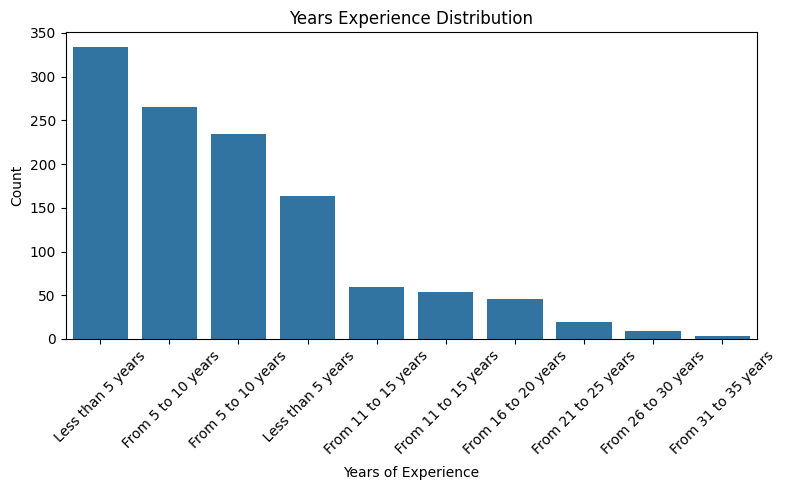

In [57]:
plt.figure(figsize=(8,5))

order = df["Years_Experience"].value_counts().index

sns.countplot(
    data=df,
    x="Years_Experience",
    order=order
)

plt.title("Years Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

هنا لازم تعديل غالبا مسافات

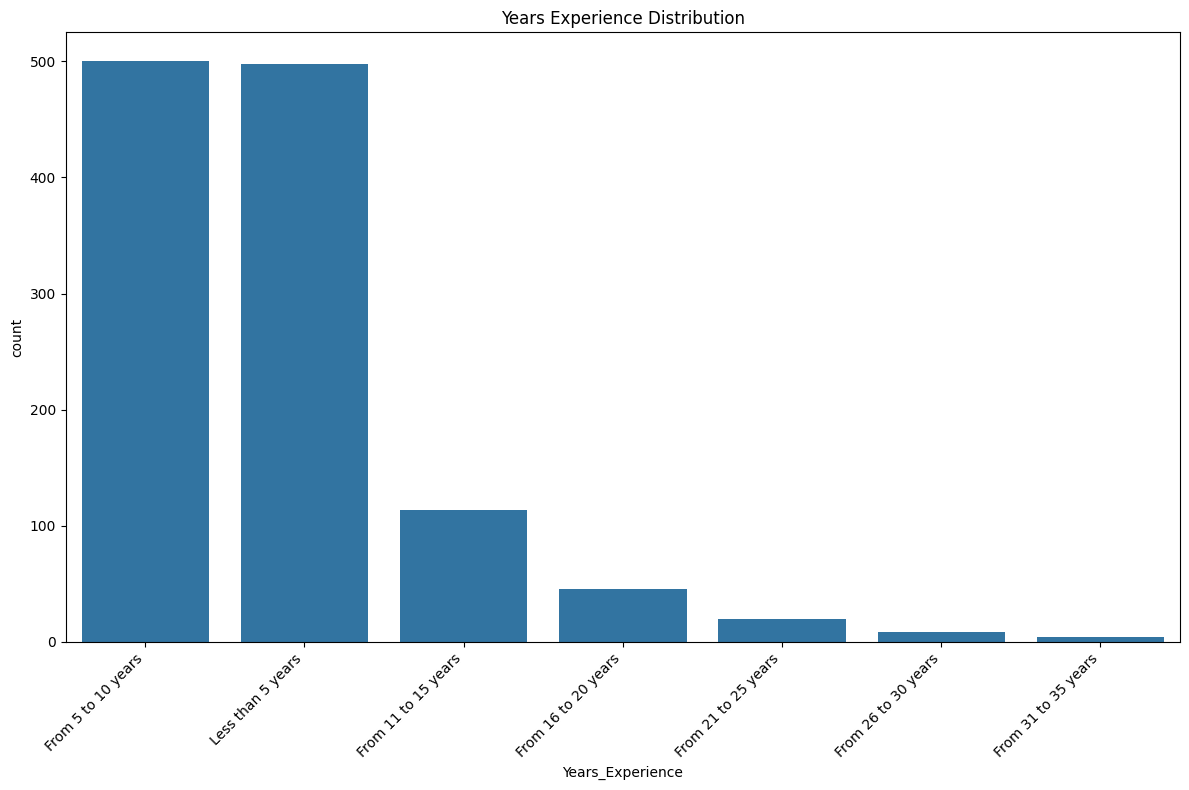

In [58]:
df["Years_Experience"] = df["Years_Experience"].str.strip()
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    x="Years_Experience",
    order=df["Years_Experience"].value_counts().index
)

plt.title("Years Experience Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


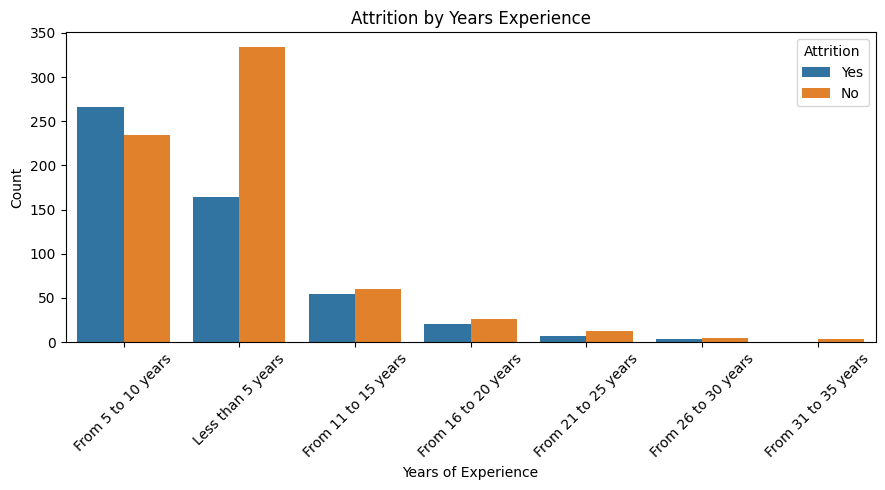

In [59]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Years_Experience",
    hue="Attrition",
    order=df["Years_Experience"].value_counts().index
)

plt.title("Attrition by Years Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Years experience last organization

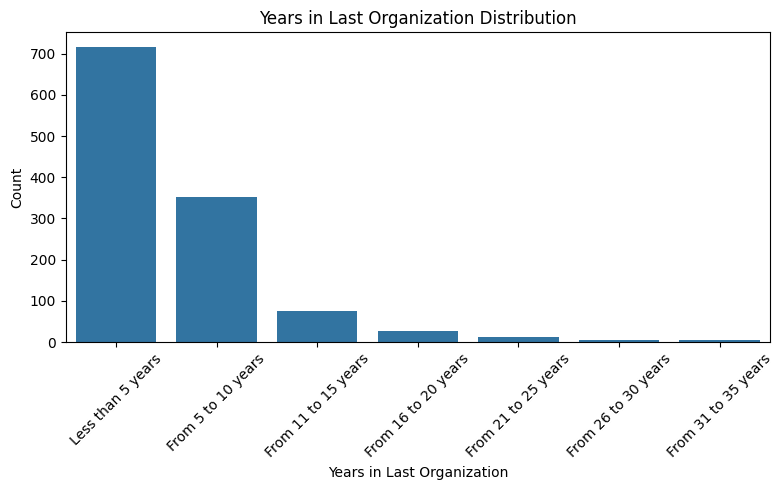

In [60]:
df["Years_experience_lastorganization"] = df["Years_experience_lastorganization"].str.strip()

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Years_experience_lastorganization",
    order=df["Years_experience_lastorganization"].value_counts().index
)

plt.title("Years in Last Organization Distribution")
plt.xlabel("Years in Last Organization")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


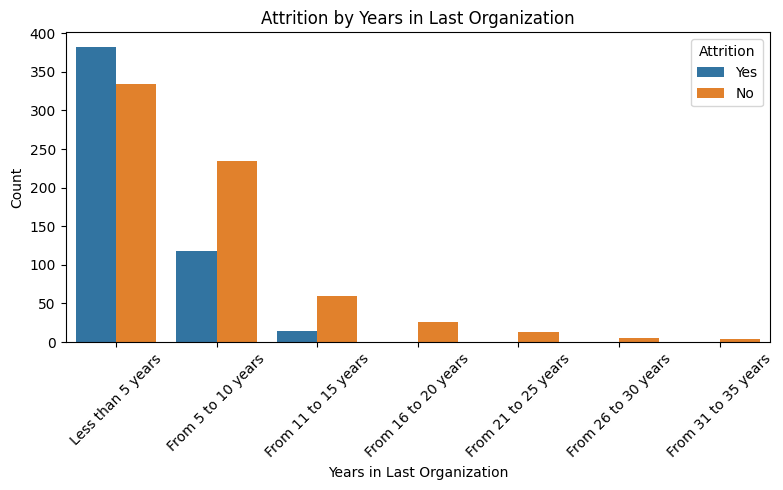

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Years_experience_lastorganization",
    hue="Attrition",
    order=df["Years_experience_lastorganization"].value_counts().index
)

plt.title("Attrition by Years in Last Organization")
plt.xlabel("Years in Last Organization")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bonus Analysis

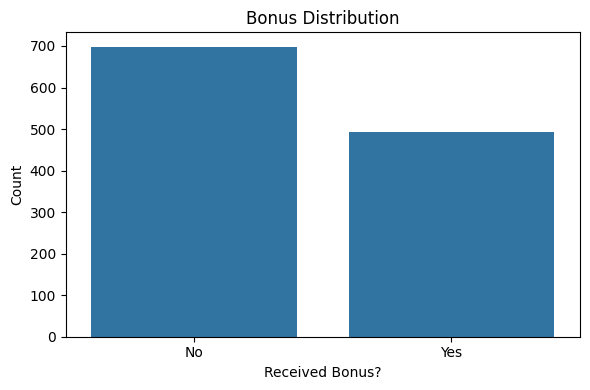

In [62]:
plt.figure(figsize=(6,4))
bonus_order = df["Bonus"].value_counts().index

sns.countplot(data=df, x="Bonus", order=bonus_order)
plt.title("Bonus Distribution")
plt.xlabel("Received Bonus?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


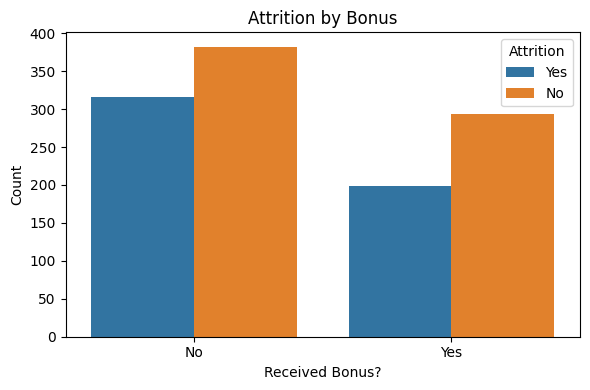

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Bonus", hue="Attrition", order=bonus_order)
plt.title("Attrition by Bonus")
plt.xlabel("Received Bonus?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [64]:
print("Attrition Rate by Bonus")

rate = (
    df.groupby("Bonus")["Attrition_num"]
    .mean() * 100
).round(1)

print(rate)

Attrition Rate by Bonus
Bonus
No     45.3
Yes    40.4
Name: Attrition_num, dtype: float64


Employees without bonuses show a  higher attrition rate 45.3%  then those receiving bonuses 40.4%. 


### Job Opportunities Analysis


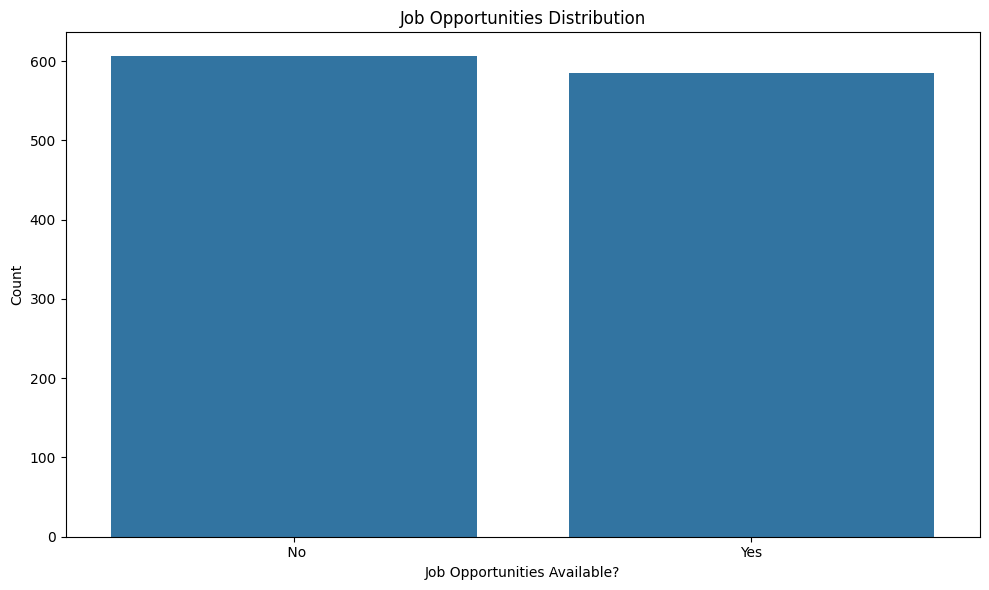

In [65]:
plt.figure(figsize=(10,6))
jobs_order = df["Job_Opportunities"].value_counts().index

sns.countplot(data=df, x="Job_Opportunities", order=jobs_order)
plt.title("Job Opportunities Distribution")
plt.xlabel("Job Opportunities Available?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


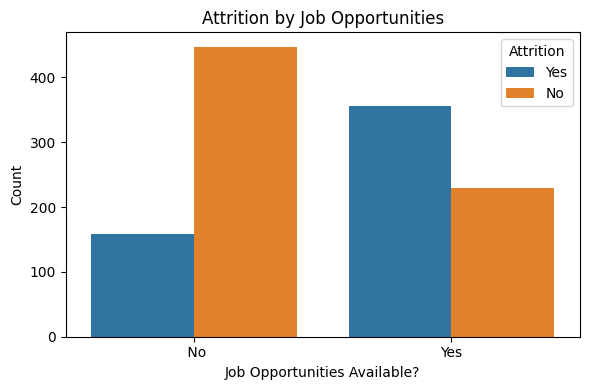

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Job_Opportunities", hue="Attrition", order=jobs_order)
plt.title("Attrition by Job Opportunities")
plt.xlabel("Job Opportunities Available?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Emotional Commitment Analysis


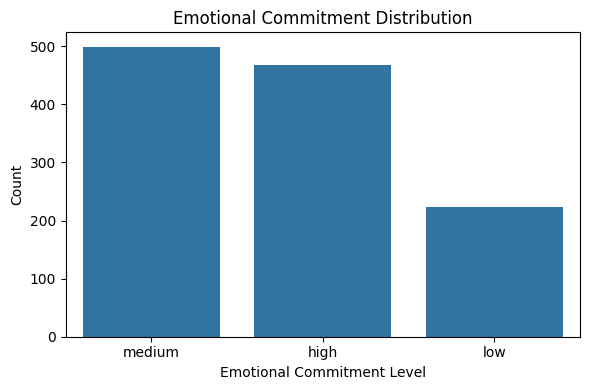

In [67]:
plt.figure(figsize=(6,4))
commit_order = df["Emotional_Commitment"].value_counts().index

sns.countplot(data=df, x="Emotional_Commitment", order=commit_order)
plt.title("Emotional Commitment Distribution")
plt.xlabel("Emotional Commitment Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


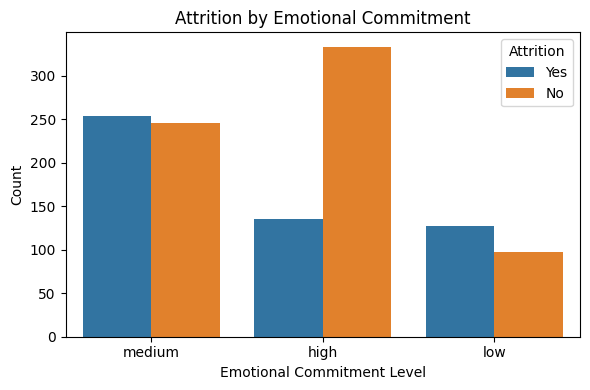

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Emotional_Commitment", hue="Attrition", order=commit_order)
plt.title("Attrition by Emotional Commitment")
plt.xlabel("Emotional Commitment Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Emotional commitment represents one of the core psychological predictors of attrition in this dataset.

### Health Issues Analysis


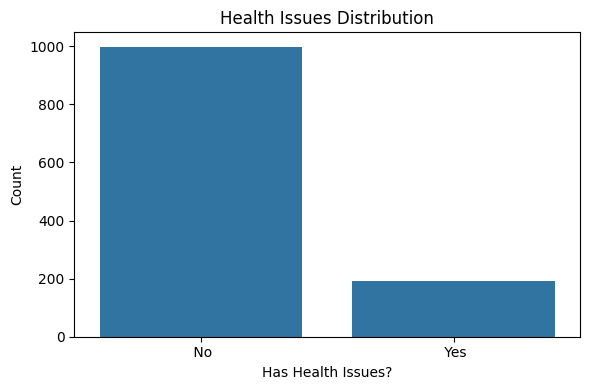

In [69]:
plt.figure(figsize=(6,4))
health_order = df["Health_Issues"].value_counts().index

sns.countplot(data=df, x="Health_Issues", order=health_order)
plt.title("Health Issues Distribution")
plt.xlabel("Has Health Issues?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


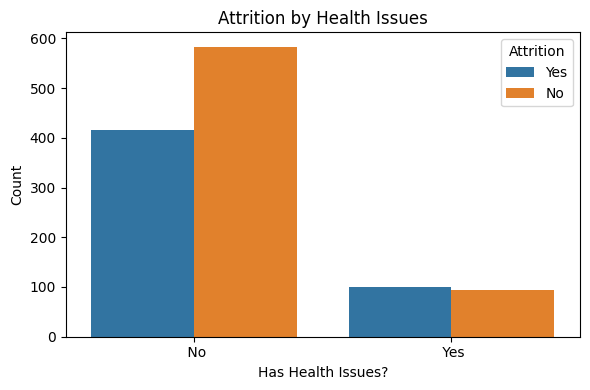

In [70]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Health_Issues", hue="Attrition", order=health_order)
plt.title("Attrition by Health Issues")
plt.xlabel("Has Health Issues?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Rewards & Wages Satisfaction Analysis


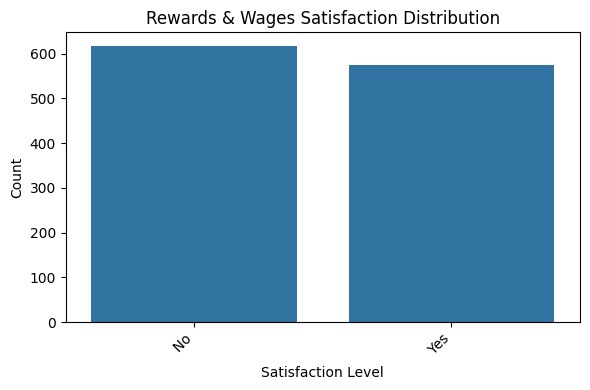

In [71]:
plt.figure(figsize=(6,4))
rewards_order = df["Rewards&Wages_Satisfaction"].value_counts().index

sns.countplot(data=df, x="Rewards&Wages_Satisfaction", order=rewards_order)
plt.title("Rewards & Wages Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


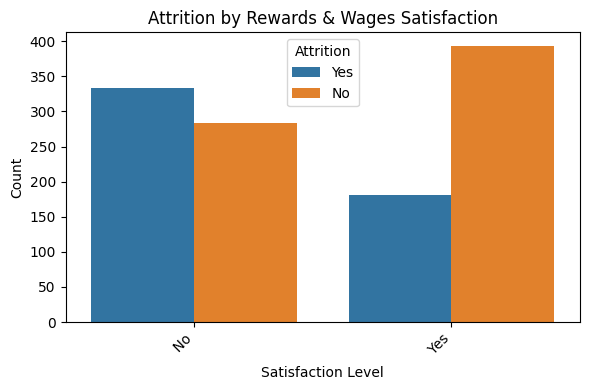

In [72]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Rewards&Wages_Satisfaction",
              hue="Attrition", order=rewards_order)
plt.title("Attrition by Rewards & Wages Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Compensation satisfaction  a strong association with attrition. Employees dissatisfied with rewards and wages exhibit substantially higher  rates, show financial fairness perception as a major retention driver.


## Relationship

### Relationship: Salary vs OverTime


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


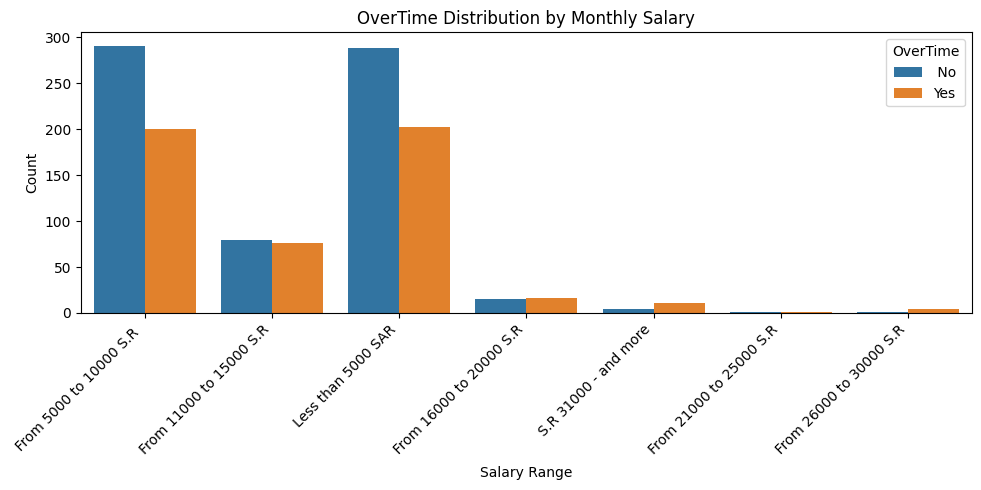

In [73]:
# هل اللي راتبه قليل يشتغل أوفر تايم أكثر؟
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="MonthlySalary",
    hue="OverTime",

)
plt.title("OverTime Distribution by Monthly Salary")
plt.xlabel("Salary Range")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


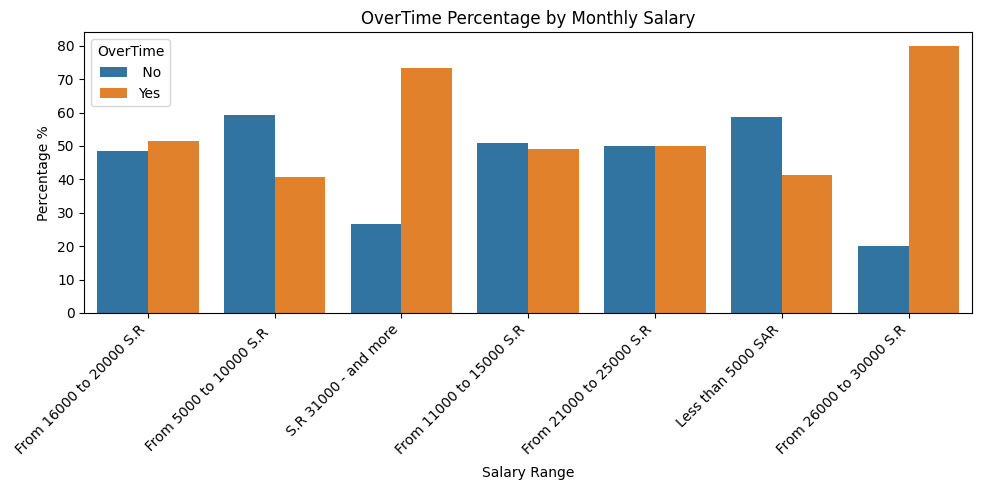

In [74]:

# نسبة % الأوفر تايم لكل فئة راتب
salary_ot = df.groupby(["MonthlySalary", "OverTime"]).size().reset_index(name="count")
salary_ot["percentage"] = (
    salary_ot.groupby("MonthlySalary")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=salary_ot,
    x="MonthlySalary",
    y="percentage",
    hue="OverTime",
)
plt.title("OverTime Percentage by Monthly Salary")
plt.xlabel("Salary Range")
plt.ylabel("Percentage %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [75]:
# حساب النسبة المئوية
overtime_pct = (
    df.groupby("MonthlySalary")["OverTime"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

# ترتيب الفئات حسب عدد الموظفين
salary_order = df["MonthlySalary"].value_counts().index
overtime_pct["MonthlySalary"] = pd.Categorical(
    overtime_pct["MonthlySalary"],
    categories=salary_order,
    ordered=True
)

overtime_pct = overtime_pct.sort_values(["MonthlySalary", "OverTime"])

for salary in salary_order:
    subset = overtime_pct[overtime_pct["MonthlySalary"] == salary]
    
    print(f"Salary Range: {salary}")
    print("-------------------------------------")
    
    for _, row in subset.iterrows():
        pct = round(row["Percentage"], 1)
        print(f"  OverTime = {row['OverTime']:<5} {pct:>5}% ")


Salary Range: Less than 5000 SAR
-------------------------------------
  OverTime =  No    58.7% 
  OverTime = Yes    41.3% 
Salary Range:  From 5000 to 10000 S.R 
-------------------------------------
  OverTime =  No    59.3% 
  OverTime = Yes    40.7% 
Salary Range: From 11000 to 15000 S.R
-------------------------------------
  OverTime =  No    51.0% 
  OverTime = Yes    49.0% 
Salary Range:  From 16000 to 20000 S.R
-------------------------------------
  OverTime =  No    48.4% 
  OverTime = Yes    51.6% 
Salary Range:  S.R 31000 - and more
-------------------------------------
  OverTime =  No    26.7% 
  OverTime = Yes    73.3% 
Salary Range:  From 26000 to 30000 S.R
-------------------------------------
  OverTime =  No    20.0% 
  OverTime = Yes    80.0% 
Salary Range: From 21000 to 25000 S.R
-------------------------------------
  OverTime =  No    50.0% 
  OverTime = Yes    50.0% 


Overtime work appears more prevalent among higher salar

### Relationship: OverTime vs Psychological Exhaustion


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


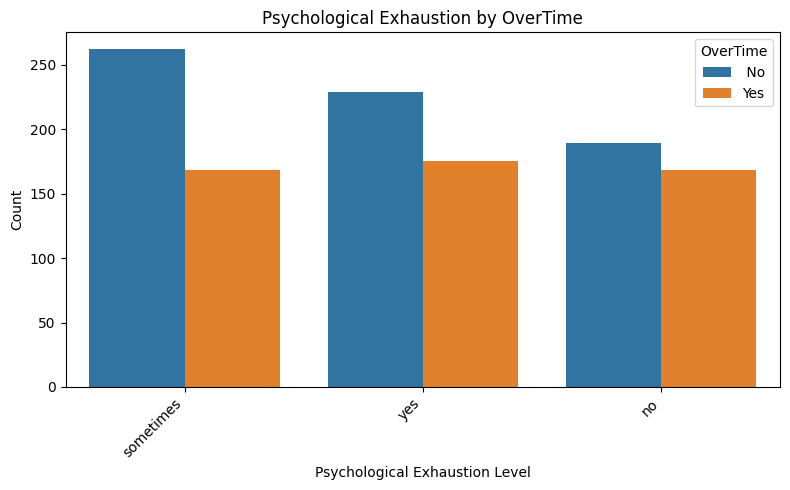

In [76]:
# توزيع الإرهاق النفسي حسب الأوفر تايم
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Psychological_Exhaustion",
    hue="OverTime",
    order=df["Psychological_Exhaustion"].value_counts().index
)
plt.title("Psychological Exhaustion by OverTime")
plt.xlabel("Psychological Exhaustion Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [77]:
rate = (
    df.groupby("Psychological_Exhaustion")["OverTime"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(1)
)

print(rate)

Psychological_Exhaustion
no           47.1
sometimes    39.1
yes          43.3
Name: OverTime, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


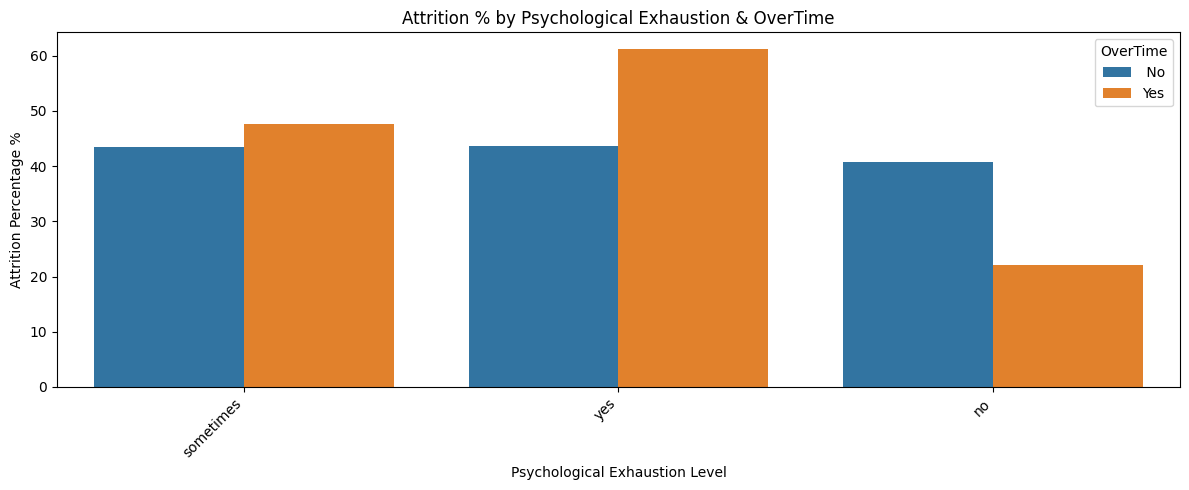

In [78]:
# العلاقة بين: OverTime + Exhaustion + Attrition
exhaust_ot_attr = (
    df.groupby(["OverTime", "Psychological_Exhaustion", "Attrition"])
    .size()
    .reset_index(name="count")
)

exhaust_ot_attr["percentage"] = (
    exhaust_ot_attr.groupby(["OverTime", "Psychological_Exhaustion"])["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=exhaust_ot_attr[exhaust_ot_attr["Attrition"] == "Yes"],
    x="Psychological_Exhaustion",
    y="percentage",
    hue="OverTime",
    order=df["Psychological_Exhaustion"].value_counts().index
)
plt.title("Attrition % by Psychological Exhaustion & OverTime")
plt.xlabel("Psychological Exhaustion Level")
plt.ylabel("Attrition Percentage %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Overtime alone does not  increase attrition  when combined with psychological exhaustion turnover risk escalates sharply.

### Relationship: Promotion vs Job Satisfaction


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


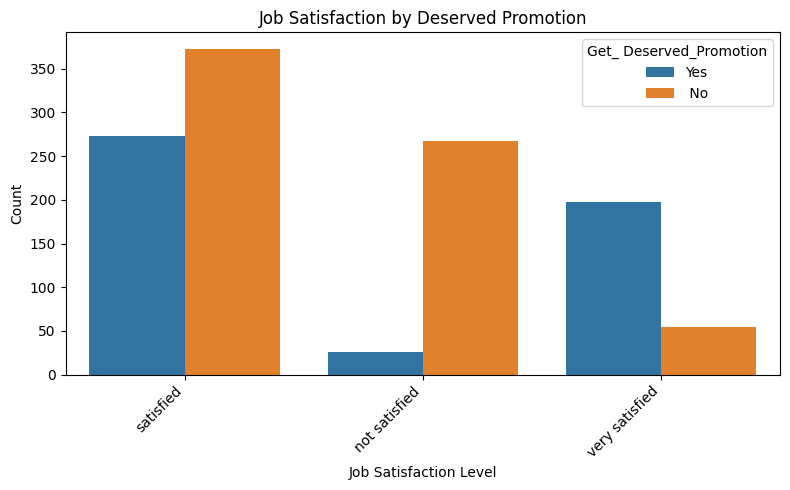

In [79]:
# توزيع الرضا الوظيفي حسب الترقية
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Job_Satisfaction",
    hue="Get_ Deserved_Promotion",
    order=df["Job_Satisfaction"].value_counts().index
)
plt.title("Job Satisfaction by Deserved Promotion")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Who didn’t get a deserved promotion

The ratio of not satisfied is higher

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


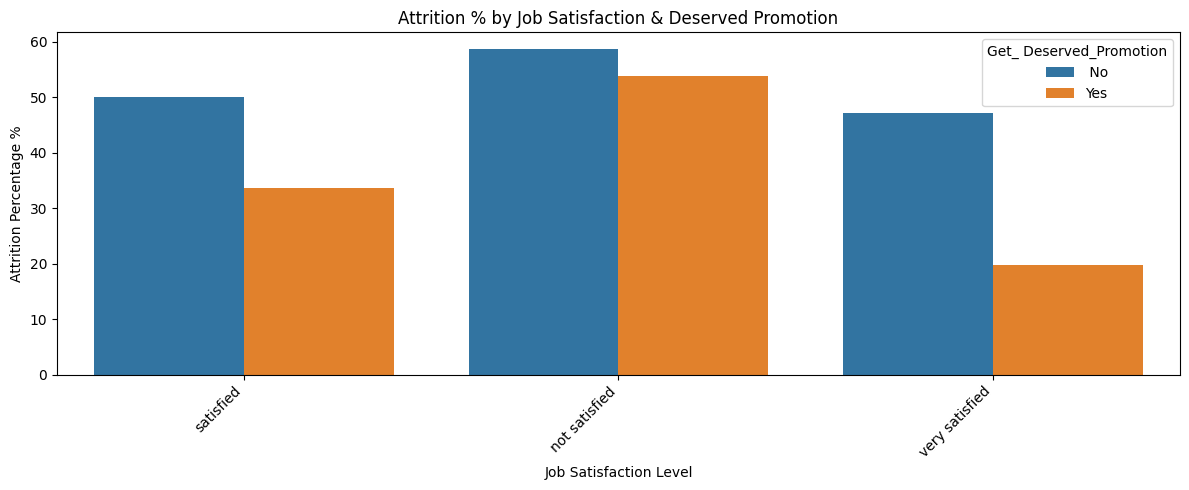

In [80]:

# العلاقة بين: Promotion + Job_Satisfaction + Attrition
promo_sat_attr = (
    df.groupby(["Get_ Deserved_Promotion", "Job_Satisfaction", "Attrition"])
    .size()
    .reset_index(name="count")
)

promo_sat_attr["percentage"] = (
    promo_sat_attr.groupby(["Get_ Deserved_Promotion", "Job_Satisfaction"])["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=promo_sat_attr[promo_sat_attr["Attrition"] == "Yes"],
    x="Job_Satisfaction",
    y="percentage",
    hue="Get_ Deserved_Promotion",
    order=df["Job_Satisfaction"].value_counts().index
)
plt.title("Attrition % by Job Satisfaction & Deserved Promotion")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Percentage %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Not satisfied + No promotion
 ~59% Attrition

Very satisfied + Promotion
 ~20% Attrition
فرق  جدا.

### Relationship: Years Experience vs Monthly Salary


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

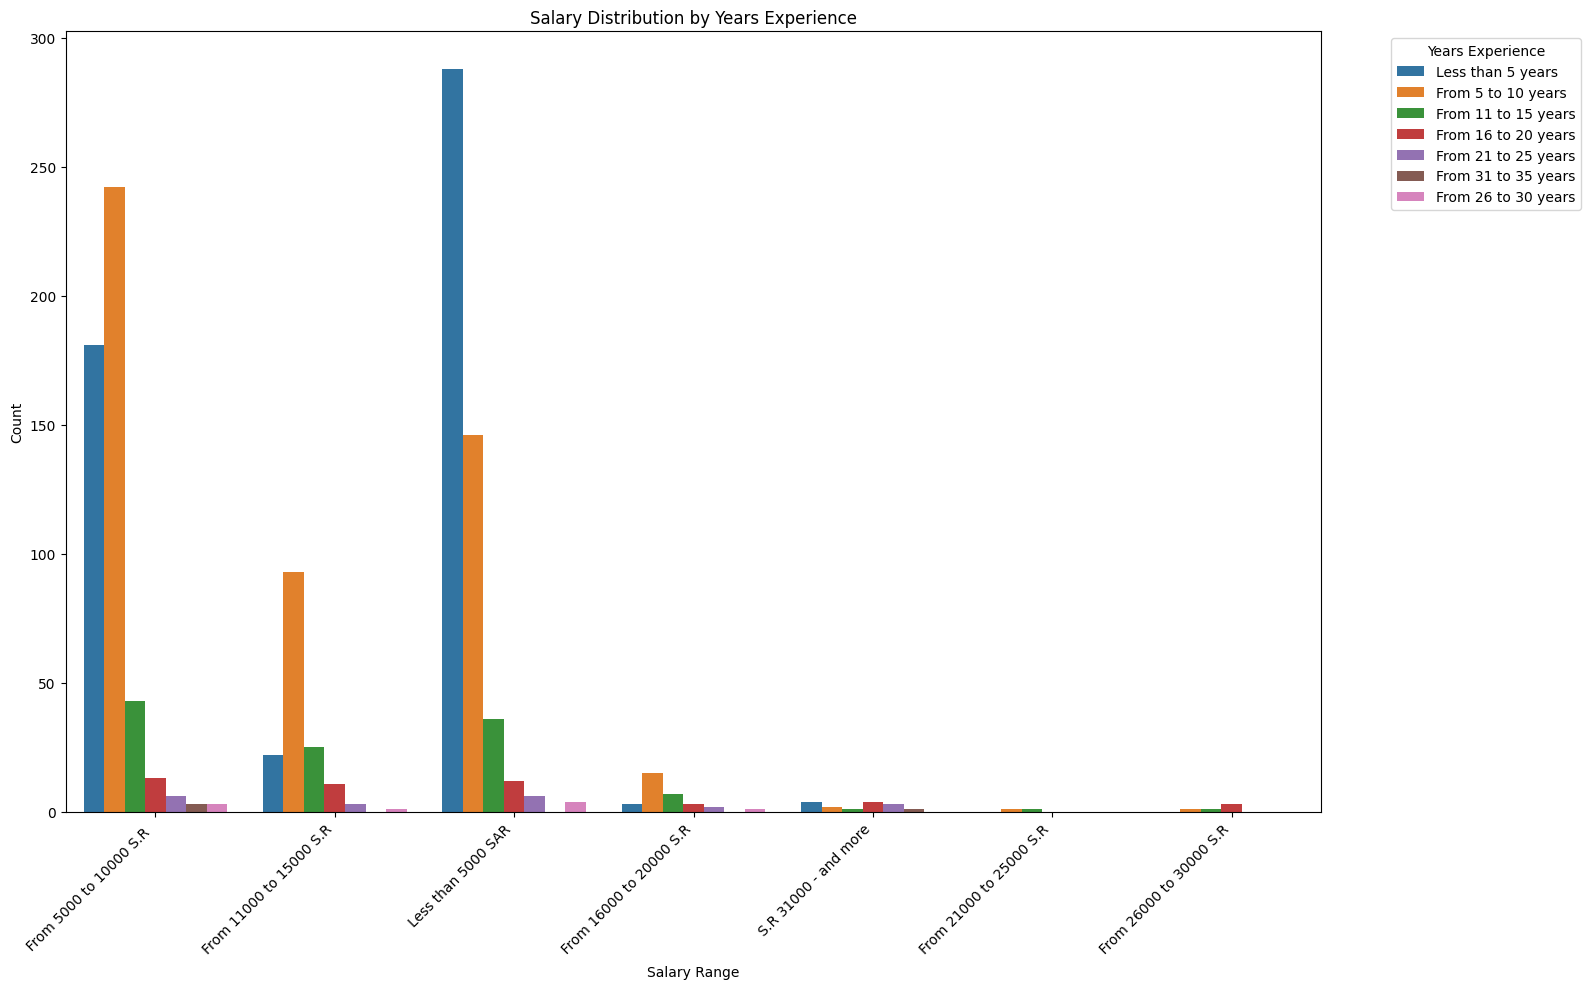

In [81]:
# توزيع الرواتب حسب سنوات الخبرة
plt.figure(figsize=(16,10))
sns.countplot(
    data=df,
    x="MonthlySalary",
    hue="Years_Experience",
)
plt.title("Salary Distribution by Years Experience")
plt.xlabel("Salary Range")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Years Experience", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

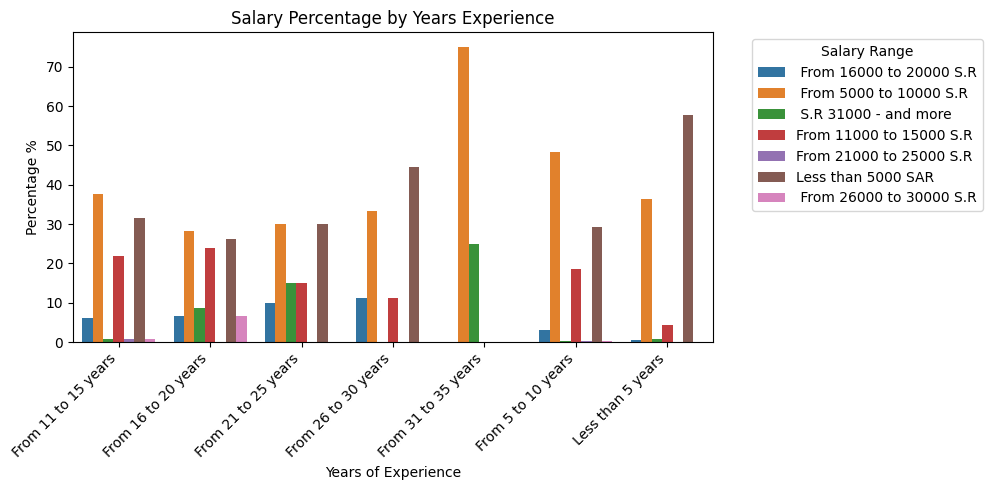

In [82]:
# نسبة % الراتب لكل فئة خبرة
exp_sal = df.groupby(["Years_Experience", "MonthlySalary"]).size().reset_index(name="count")
exp_sal["percentage"] = (
    exp_sal.groupby("Years_Experience")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=exp_sal,
    x="Years_Experience",
    y="percentage",
    hue="MonthlySalary",
 )
plt.title("Salary Percentage by Years Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Percentage %")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Salary Range", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



This chart shows how salary levels are distributed across different years of experience 

Most employees with less than 10 years of experience are in the lower salary ranges  especially below 10,000 SAR 

As years of experience increas  the percentage of employees in higher salary ranges becomes slightly higher

Employees with more than 25 or 30 years of experience are fewer in number  but some of them earn higher salaries

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

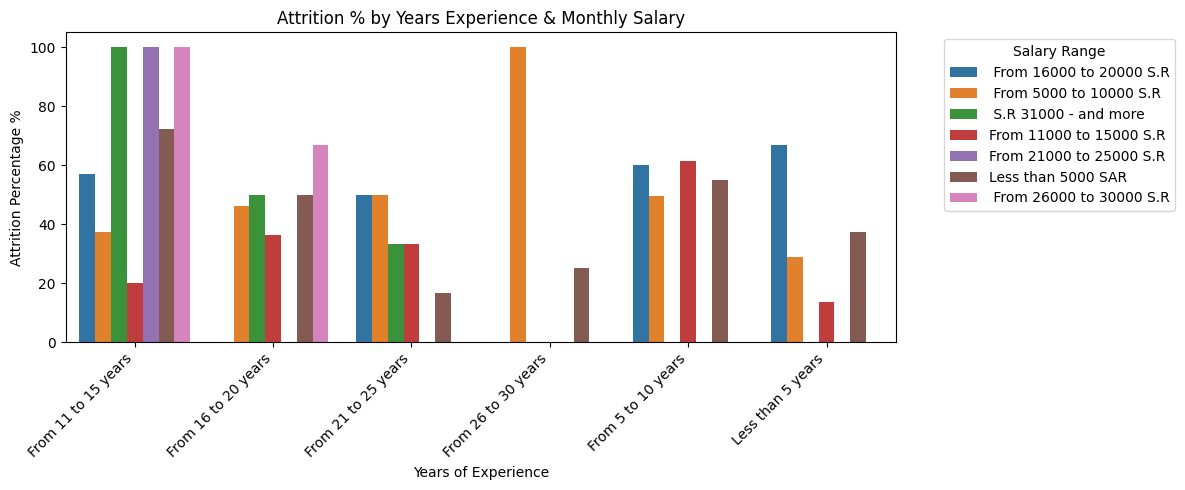

In [83]:
# العلاقة بين: Experience + Salary + Attrition
exp_sal_attr = (
    df.groupby(["Years_Experience", "MonthlySalary", "Attrition"])
    .size()
    .reset_index(name="count")
)

exp_sal_attr["percentage"] = (
    exp_sal_attr.groupby(["Years_Experience", "MonthlySalary"])["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=exp_sal_attr[exp_sal_attr["Attrition"] == "Yes"],
    x="Years_Experience",
    y="percentage",
    hue="MonthlySalary",
)
plt.title("Attrition % by Years Experience & Monthly Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Attrition Percentage %")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Salary Range", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [84]:

attr_yes = exp_sal_attr[exp_sal_attr["Attrition"] == "Yes"]

# إنشاء Pivot Table
pivot_table = attr_yes.pivot_table(
    index="Years_Experience",
    columns="MonthlySalary",
    values="percentage"
).round(1)

print("Attrition % by Years Experience & Monthly Salary")
pivot_table.fillna(0)


Attrition % by Years Experience & Monthly Salary


MonthlySalary,From 16000 to 20000 S.R,From 5000 to 10000 S.R,S.R 31000 - and more,From 11000 to 15000 S.R,From 21000 to 25000 S.R,Less than 5000 SAR,From 26000 to 30000 S.R
Years_Experience,,,,,,,
From 11 to 15 years,57.1,37.2,100.0,20.0,100.0,72.2,100.0
From 16 to 20 years,0.0,46.2,50.0,36.4,0.0,50.0,66.7
From 21 to 25 years,50.0,50.0,33.3,33.3,0.0,16.7,0.0
From 26 to 30 years,0.0,100.0,0.0,0.0,0.0,25.0,0.0
From 5 to 10 years,60.0,49.6,0.0,61.3,0.0,54.8,0.0
Less than 5 years,66.7,28.7,0.0,13.6,0.0,37.2,0.0


Attrition risk increases when compensation does not align with career stage expectations.

### Relationship: Age vs Emotional Commitment


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

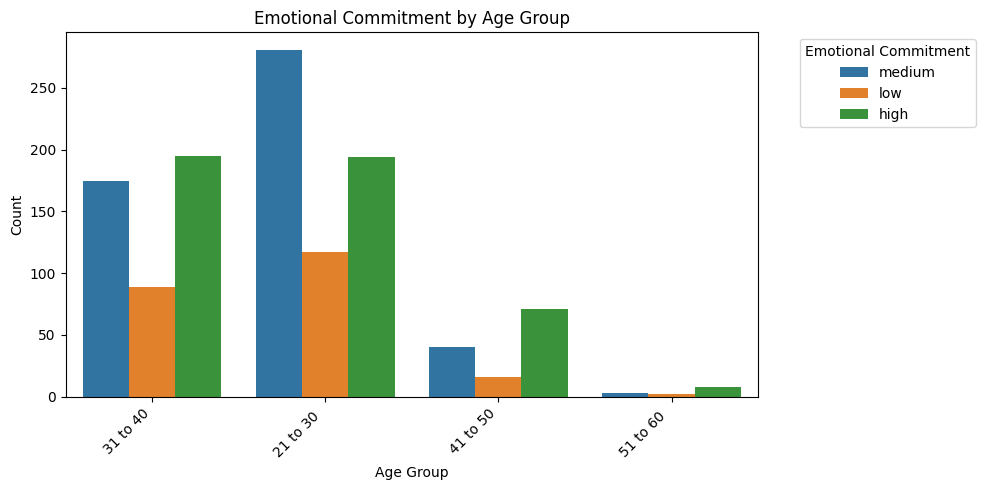

In [85]:
# توزيع الارتباط العاطفي حسب الفئة العمرية
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Age",
    hue="Emotional_Commitment",

)
plt.title("Emotional Commitment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Emotional Commitment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

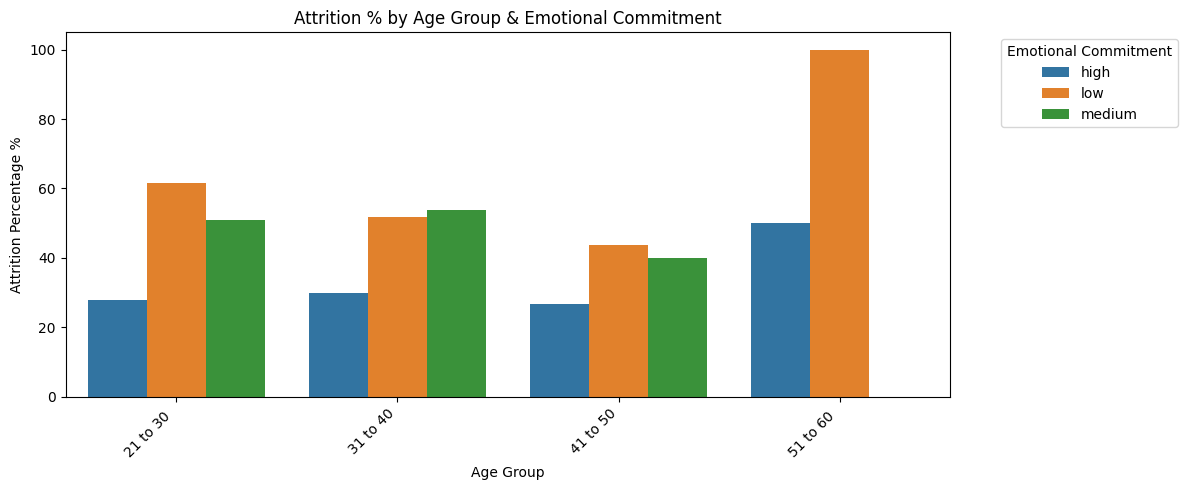

In [86]:

# العلاقة بين: Age + Emotional_Commitment + Attrition
age_commit_attr = (
    df.groupby(["Age", "Emotional_Commitment", "Attrition"])
    .size()
    .reset_index(name="count")
)

age_commit_attr["percentage"] = (
    age_commit_attr.groupby(["Age", "Emotional_Commitment"])["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=age_commit_attr[age_commit_attr["Attrition"] == "Yes"],
    x="Age",
    y="percentage",
    hue="Emotional_Commitment",

)
plt.title("Attrition % by Age Group & Emotional Commitment")
plt.xlabel("Age Group")
plt.ylabel("Attrition Percentage %")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Emotional Commitment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Emotional commitment appears to be a stronger predictor of attrition than age group.

## SECTION 2 — Key Insights & Findings

In this section we summarize the most important findings from the EDA and highlight the top factors that drive employee attrition in the organization


In [87]:
total_employees = len(df)
bonus_count = (df["Bonus"] == "Yes").sum()
medical_count = (df["MedicalInsurance"] == "Yes").sum()
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

html_code = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1; padding:20px; border-radius:15px; background:#f4f4f4; text-align:center;">
<h3>👥 Total Employees</h3>
<h1 style="color:#4CAF93;">{total_employees:,}</h1>
</div>

<div style="flex:1; padding:20px; border-radius:15px; background:#f4f4f4; text-align:center;">
<h3>🎁 Received Bonus</h3>
<h1 style="color:#7E8CE0;">{bonus_count:,}</h1>
</div>

<div style="flex:1; padding:20px; border-radius:15px; background:#f4f4f4; text-align:center;">
<h3>💊 With Medical Insurance</h3>
<h1 style="color:#A778E0;">{medical_count:,}</h1>
</div>

<div style="flex:1; padding:20px; border-radius:15px; background:#f4f4f4; text-align:center;">
<h3>📉 Attrition Rate</h3>
<h1 style="color:#E78FA6;">{attrition_rate:.1f}%</h1>
</div>

</div>
"""

display(HTML(html_code))

In [88]:
gender_counts = df["Gender"].value_counts()
labels = gender_counts.index
values = gender_counts.values

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.55,  # يخليها donut
    marker=dict(
        colors=["#9DA9E0", "#A8D88F"],  # Female / Male
        line=dict(color="white", width=3)
    ),
    textinfo="percent",
    hovertemplate="<b>%{label}</b><br>Value: %{value}<br>Percentage: %{percent}<extra></extra>"
)])

fig.update_layout(
    title={
        "text": "<b>Workforce Distribution by Gender</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5
    ),
    width=750,
    height=550
)

fig.show()

Key Insights

majority one gender approximately 57% with the other representing roughly 43%, indicating a noticeable gender imbalance



In [89]:

age_attr = (
    df.groupby(["Age", "Attrition"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

fig = go.Figure()

# Attrition = Yes
fig.add_trace(go.Bar(
    x=age_attr["Age"],
    y=age_attr["Yes"],
    name="Yes",
    marker_color="#9DA9E0",
    text=age_attr["Yes"],
    textposition="inside"
))

# Attrition = No
fig.add_trace(go.Bar(
    x=age_attr["Age"],
    y=age_attr["No"],
    name="No",
    marker_color="#A8D88F",
    text=age_attr["No"],
    textposition="inside"
))

fig.update_layout(
    barmode="stack",
    title={
        "text": "<b>Attrition by Age Group</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Age Group",
    yaxis_title="Count",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    ),
    width=850,
    height=500,
    plot_bgcolor="white"
)

fig.show()

Key Insights

The youngest age groups show the largest absolute numbers of both attrition (Yes) and retention (No), show concentration of workforce and turnover in those cohorts.

Attrition (Yes) is proportionally highest in specific younger to mid age brackets compared with older groups suggesting retention issues earlier in employee lifecycle.

In [90]:
df["Department"] = (
    df["Department"]
    .str.strip()        # يشيل المسافات
    .str.lower()        # يخليها كلها small
)
df["Department"] = df["Department"].str.title()
dept_attr = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    .reset_index()
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=dept_attr["Department"],
    y=dept_attr["Attrition"],
    marker_color="#9DA9E0",
    text=dept_attr["Attrition"].round(2),
    textposition="outside"
))

fig.update_layout(
    title={
        "text": "<b>Attrition Rate by Department</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Department",
    yaxis_title="Attrition Rate",
    yaxis=dict(tickformat=".0%"),
    width=1000,
    height=550,
    plot_bgcolor="white"
)

fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Attrition Rate: %{y:.2%}<extra></extra>"
)

fig.show()

Key Insights

A small number of departments have exceptionally high attrition rates (values at or near 1.0 on the chart), highlighting acute retention problems in those areas.

Many departments cluster at moderate attrition rates (0.4–0.8), but the extreme outliers indicate targeted intervention is needed in top-ranking departments.

In [91]:

# حساب عدد الموظفين لكل قطاع
sector_counts = (
    df["Sector"]
    .value_counts()
    .sort_values(ascending=True)   # عشان يكون أفقي مرتب
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=sector_counts.values,
    y=sector_counts.index,
    orientation="h",
    marker_color="#9DA9E0",
    text=sector_counts.values,
    textposition="outside"
))

fig.update_layout(
    title={
        "text": "<b>Headcount by Sector</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Headcount",
    yaxis_title="",
    width=900,
    height=550,
    plot_bgcolor="white",
    margin=dict(l=200, r=40, t=80, b=40)
)

fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Headcount: %{x}<extra></extra>"
)

fig.show()

Key Insights

The Medical, education and Financial sectors dominate headcount (over 300 and ~150 respectively), representing the majority of employees across sectors.

Several sectors (Transport, Economic, Environment/Agriculture, Tourism and smaller ones) have much lower headcounts, indicating workforce concentration in a few key sectors.

In [92]:
eng_data = (
    df.groupby(["Work_Live_Balance", "Job_Satisfaction"])["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index()
)

eng_data["Label"] = (
    eng_data["Work_Live_Balance"] + " - " +
    eng_data["Job_Satisfaction"]
)

eng_data = eng_data.sort_values("Attrition", ascending=False)


comp_data = (
    df.groupby("MonthlySalary")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index()
    .sort_values("Attrition", ascending=False)
)


fig = make_subplots(rows=1, cols=2,
                    subplot_titles=(
                        "Attrition Rate by Engagement and Satisfaction",
                        "Attrition Rate by Compensation Band"
                    ))

# Plot 1
fig.add_trace(
    go.Bar(
        x=eng_data["Label"],
        y=eng_data["Attrition"],
        marker_color="#9DA9E0",
        text=eng_data["Attrition"].round(2),
        textposition="outside"
    ),
    row=1, col=1
)

# Plot 2
fig.add_trace(
    go.Bar(
        x=comp_data["MonthlySalary"],
        y=comp_data["Attrition"],
        marker_color="#9DA9E0",
        text=comp_data["Attrition"].round(2),
        textposition="outside"
    ),
    row=1, col=2
)

fig.update_layout(
    height=500,
    width=1200,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="#f5f6f8"
)

fig.update_xaxes(tickangle=45)

fig.show()

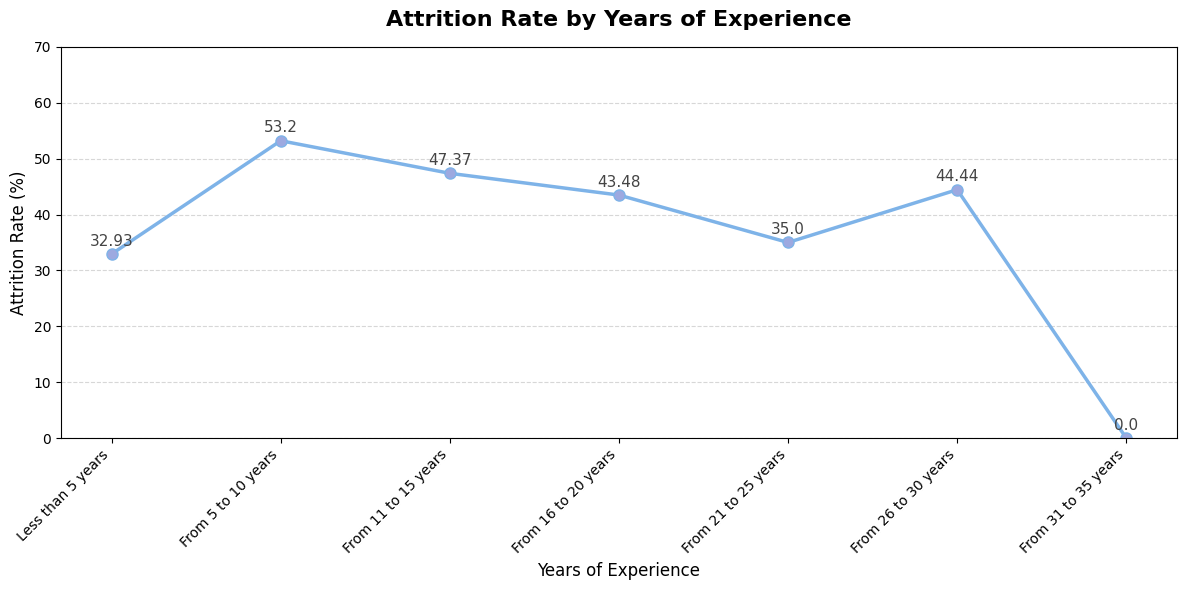

In [93]:
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
exp_rate = (
    df.groupby("Years_Experience")["Attrition_num"]
    .mean() * 100
).round(2).reset_index()
exp_rate.columns = ["Years_Experience", "Attrition_Rate"]

# ترتيب الفئات من الأقل للأكثر
exp_order = [
    "Less than 5 years",
    "From 5 to 10 years",
    "From 11 to 15 years",
    "From 16 to 20 years",
    "From 21 to 25 years",
    "From 26 to 30 years",
    "From 31 to 35 years"
]

# نحتفظ بالقيم الموجودة فقط بنفس الترتيب
exp_rate["Years_Experience"] = pd.Categorical(
    exp_rate["Years_Experience"],
    categories=exp_order,
    ordered=True
)
exp_rate = exp_rate.sort_values("Years_Experience")

# رسم الـ Line Chart
plt.figure(figsize=(12, 6))

plt.plot(
    exp_rate["Years_Experience"],
    exp_rate["Attrition_Rate"],
    color="#7EB3E8",
    marker="o",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="#9DA9E0"
)

# إضافة الأرقام فوق كل نقطة
for i, row in exp_rate.iterrows():
    plt.text(
        row["Years_Experience"],
        row["Attrition_Rate"] + 1.5,
        f'{row["Attrition_Rate"]}',
        ha="center",
        fontsize=11,
        color="#444444"
    )

plt.title("Attrition Rate by Years of Experience", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)
plt.ylim(0, 70)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Note: The "31 to 35 years" group has very few employees


In [94]:
df["JobTitle"] = df["JobTitle"].str.strip()

df["JobTitle"] = df["JobTitle"].str.title()


df["JobTitle"] = df["JobTitle"].str.replace(r"\s+", " ", regex=True)

job_stats = (
    df.groupby("JobTitle")
    .agg(
        Headcount=("Attrition", "count"),
        Attrition_Yes=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

job_stats["Attrition_Rate"] = (
    job_stats["Attrition_Yes"] / job_stats["Headcount"] * 100
).round(1)

top10 = (
    job_stats.sort_values("Attrition_Yes", ascending=False)
    .head(10)
)


fig = go.Figure(data=[go.Table(
    header=dict(
        values=["Job Title", "Attrition Yes", "Attrition Rate", "Headcount"],
        fill_color="#636EFA",
        font=dict(color="white", size=16),
        align="left",
        height=40
    ),
    cells=dict(
        values=[
            top10["JobTitle"],
            top10["Attrition_Yes"],
            top10["Attrition_Rate"].astype(str) + "%",
            top10["Headcount"]
        ],
        fill_color="white",
        align="left",
        height=35
    )
)])

fig.update_layout(
    title={
        "text": "Top 10 Job Titles by Attrition Count",
        "x": 0.02,
        "xanchor": "left",
        "font": dict(size=28)
    },
    height=550,
    paper_bgcolor="#f5f6fa"
)

fig.show()

Key Insights

Hiring Specialist stands out with a 100% attrition rate 17/17 

Several customer facing and sales roles show very high attrition rates (Sales Executive 69%, Customer Services Representative 63%, Accountant 63%) 


Some high headcount roles (e.g., Teacher, headcount 165) have relatively low attrition rates (19%), indicating role specific retention differences.

Total columns included: 34
['Attrition', 'Gender', 'Age', 'Maritalstatus', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']


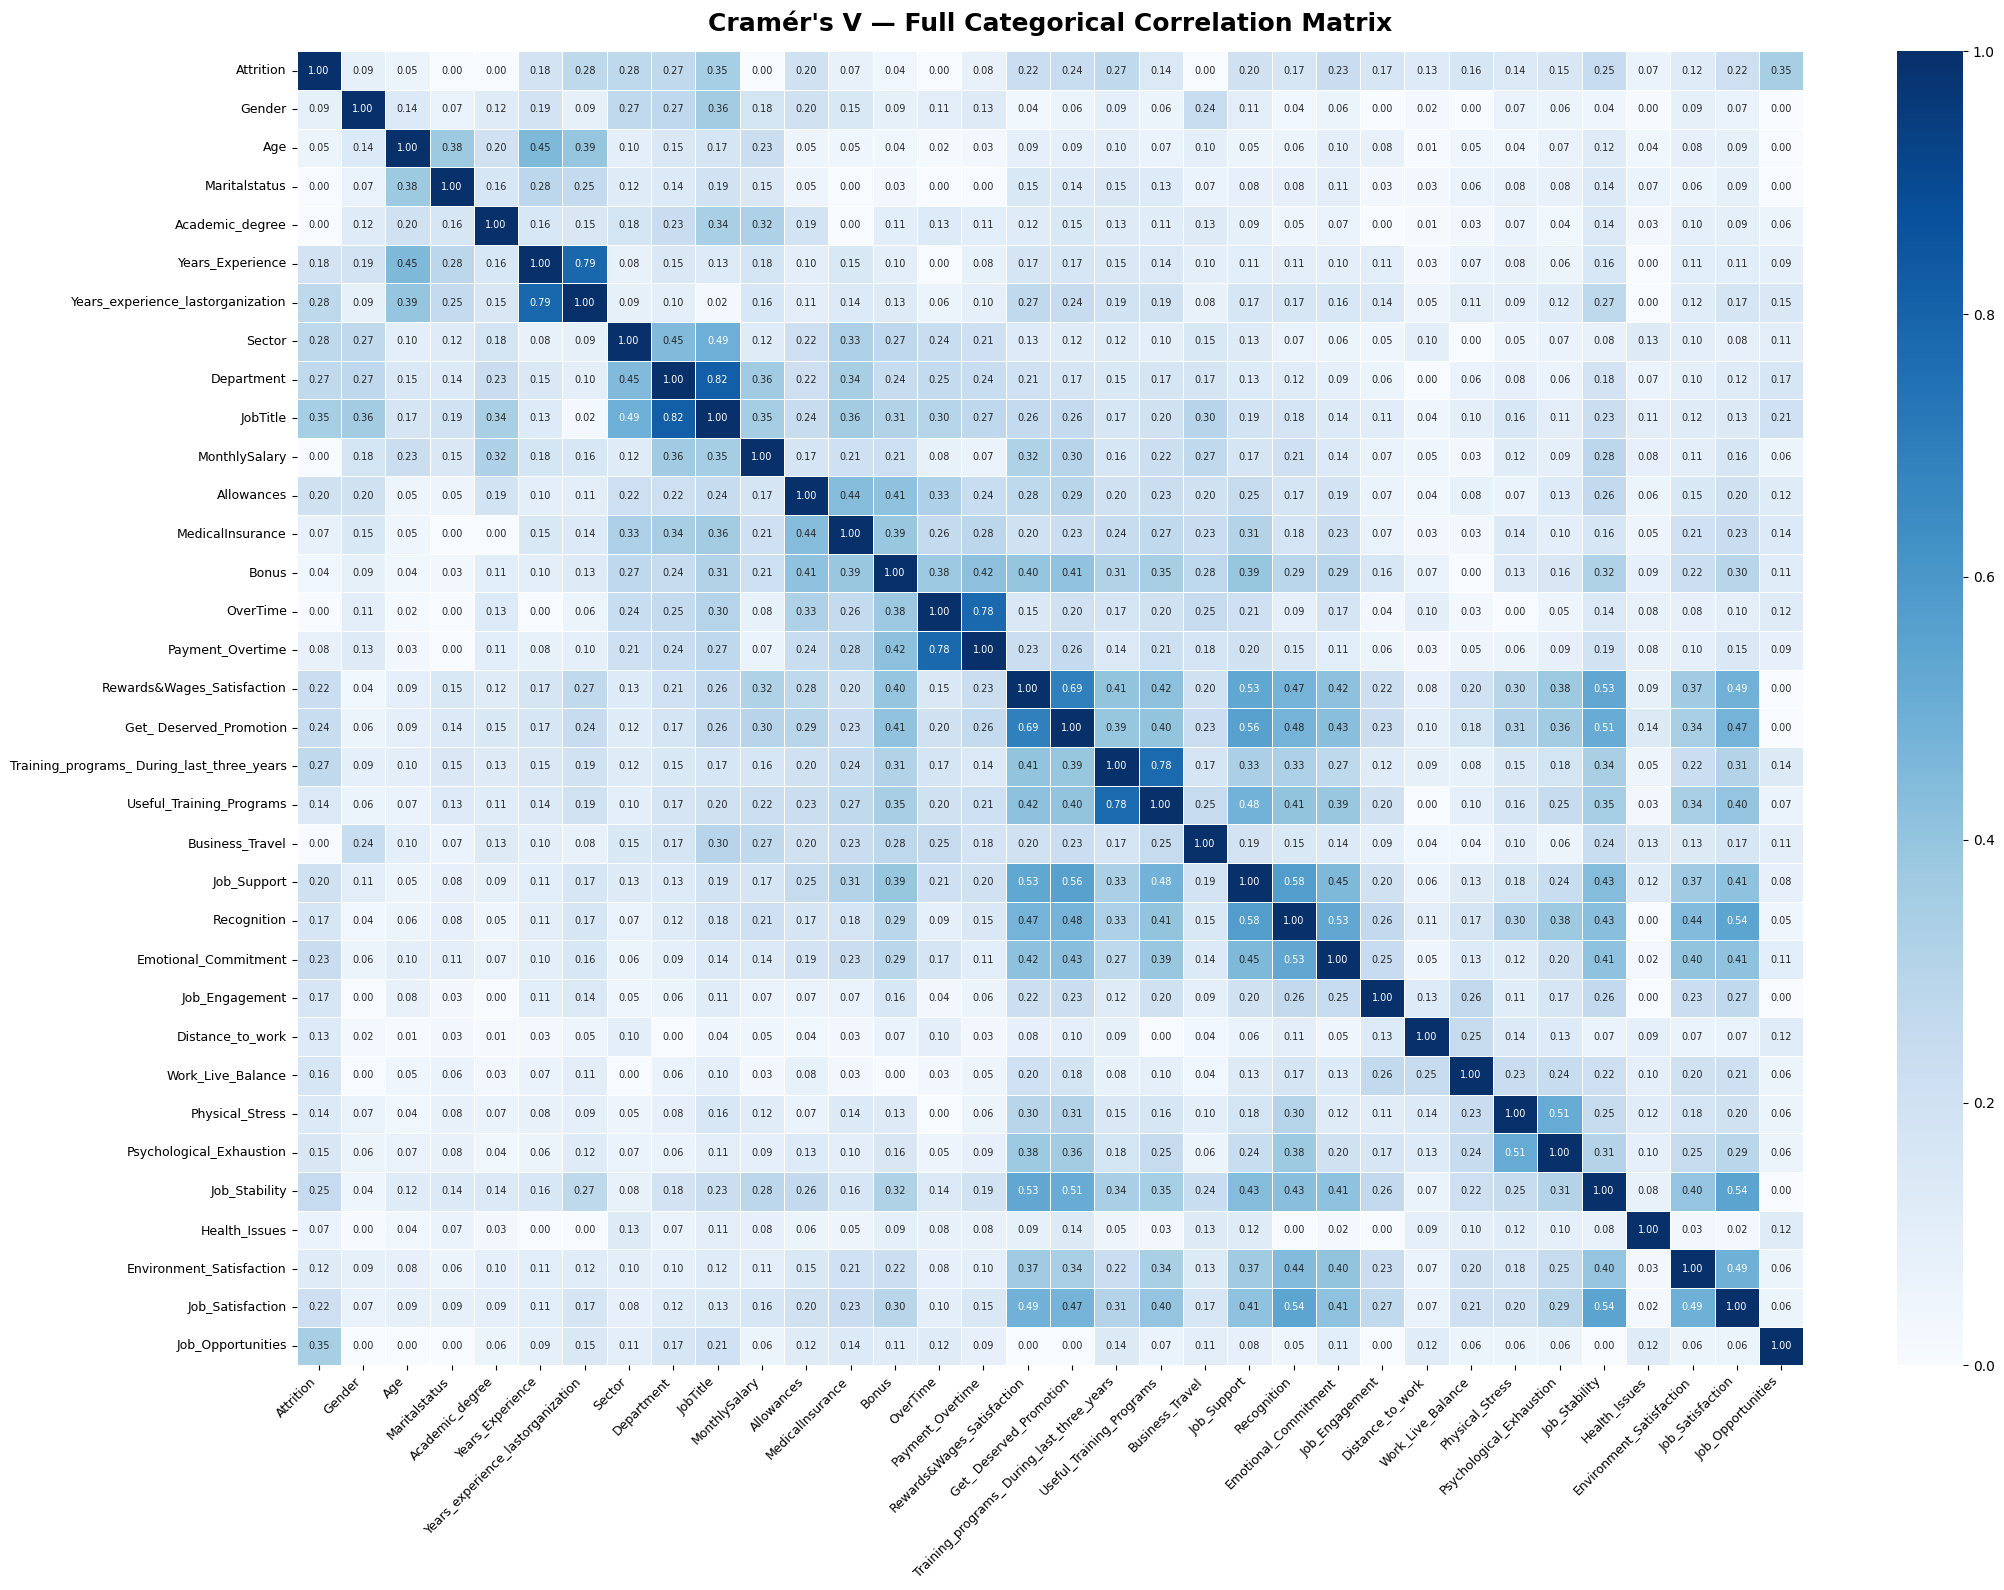

In [106]:
## Cramér's V — Full Correlation Matrix (All Columns)
# تنظيف أسماء الأعمدة
df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)

# تنظيف القيم النصية
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].apply(lambda col: col.str.strip())


cols = [c for c in df.columns if c.upper() != "ID" and c != "Attrition_num"]

print(f"Total columns included: {len(cols)}")
print(cols)

# Cramér's V

def cramers_v(x, y):
    try:
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        if n == 0:
            return 0.0
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        denom = min((kcorr-1), (rcorr-1))
        if denom <= 0:
            return 0.0
        return np.sqrt(phi2corr / denom)
    except:
        return 0.0


##cramers_matrix  


cramers_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1, col2 in itertools.product(cols, cols):
    if col1 == col2:
        cramers_matrix.loc[col1, col2] = 1.0
    else:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)


#Heatmap
plt.figure(figsize=(22, 16))

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    annot_kws={"size": 7}
)

plt.title("Cramér's V — Full Categorical Correlation Matrix",
          fontsize=18, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()



## Overall Insights

1- Workforce structure

The workforce is mostly one gender (~60%) compared to the other (~40%), showing a clear gender imbalance.

Most employees are in the younger age group  so workforce size and turnover are both highest among younger employees.

Attrition is highest in early to mid career age groups and decreases among older employee indicating retention improves with age.

---------
2- Departments & sectors

A few departments show extremely high attrition rates 

Most departments have moderate attrition  but the highest rate departments should be prioritized 

Headcount is concentrated in the Medical sector  and the Financial sector 

Several other sectors (Transport, Economic, Environment/Agriculture, Tourism, etc.) have much smaller headcounts, showing workforce concentration in a few key sectors.

----------
3-Experience

Mid-career employees (5–10 years of experience) with few or no trainings have the highest attrition (about 59–71%), suggesting a critical training gap for this group.

---------

4- Job roles

The Hiring Specialist role is an extreme anomaly with 100% attrition 

Several customer-facing and sales-related roles have high attrition (e.g., Sales Executive 69%, Customer Service Representative 63%, Accountant 63%) 

